# Class Prediction
**Background**  
- 【背景】カフェチェーンの需要予測とCRM最適化
  - あるカフェチェーン。10店舗（Store A〜J）、1万人規模のアプリ会員を持つ
  - 「ラテ」の販促キャンペーンを本部にて検討中。的確な需要予測と合理的説明をもって店舗の支持を得ながら進行したい
- 【課題】利益の最大化、店舗オペレーションの最適化、本部提案の納得感
  - 過去の失敗経験: 昨年の同様企画では予測精度が不十分で、店舗の理解も得られず、期待を下回る結果だった
  - 予算の制約: 以前にも増して本部販促費の投資対効果が注視されており、次回施策のためにも予測精度は担保したい
  - 店舗の裁量: 発注やシフト作成は店舗判断のため、納得感ある説明および行動しやすい判断材料が求められている
  
- 【問題の設定】分類予測
  - クーポン配布という施策内容に反応しやすい顧客層を特定することでROIを最大化しつつ、予測の理由を解釈しやすい判断材料を提供する
- 【解法】LGBM, Tabular DLなど
（仮案）
1. LightGBMで素早く初動回答することで、関係者合意を取り付けやすい土壌を作りやすい企画進行を支援する
1. GBDTやTabular DLなども使うことで、説明可能性や予測精度を検証
1. hoge

In [ ]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# import scipy
import sklearn
import shap
# import lightgbm as lgb
# import xgboost as xgb
import pycaret

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
import sys;print("Python", sys.version.split()[0])
import platform;print("OS", platform.platform())
print("is_google_colab:", "google.colab" in sys.modules)
from importlib.metadata import version
packages = [
"pandas",
"numpy",
"matplotlib",
"seaborn",
"scikit-learn",
"shap",
"pycaret",
]
for pkg in packages:
    try:
        print(pkg, version(pkg))
    except Exception as e:
        print(pkg, "not installed")

Created(JST) 2026-06-03 10:24:49
Python 3.10.20
OS macOS-26.5-arm64-arm-64bit
is_google_colab: False
pandas 1.5.3
numpy 1.23.5
matplotlib 3.7.4
seaborn 0.12.2
scipy 1.11.4
scikit-learn 1.2.2
shap 0.49.1
pycaret 3.0.4


In [3]:
# # サンプルのdataframeを生成する
import string

# --- 基本設定 ---
# start_date = pd.to_datetime("2025-09-01")  # 開始日
# n_days = 92  # 3ヶ月分くらいある設定にする
# n_stores = 10  # 10店舗くらいある設定にする
# n_customers = 10000  # 顧客は10000人くらい


def generate_cafe_data_v3(n_days=92, n_stores=10, n_customers=10000):
    np.random.seed(42)
    
    # --- 1. マスタ作成 ---
    store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
    dates = pd.date_range(start='2025-09-01', periods=n_days)
    
    # 顧客マスタ（10,000人）
    chars = list(string.ascii_lowercase + string.digits)
    unique_customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    customer_master = pd.DataFrame({
        'customer_id': unique_customer_ids,
        # 会員歴（年）: 指数分布っぽく（新しい人の方が多い）
        'membership_years': np.random.exponential(2, n_customers).clip(0.5, 10),
        # 過去のラテ購入率（潜在的な好みの代理指標: 存在しなくて自前で用意、定義すべきような指標かも）0.1〜0.9の間で分布
        'past_latte_ratio': np.random.beta(2, 5, n_customers),
        # 過去のクーポン利用率（感度の代理指標）
        'past_coupon_usage_rate': np.random.beta(1, 3, n_customers)
    })

    # 店舗×日付単位の外部環境マスタを作成
    env_data = []
    for d in dates:
        is_raining = np.random.binomial(1, 0.20)  # 20%の確率で雨の日
        is_weekend = 1 if d.dayofweek >= 5 else 0
        daily_temp_base = 15 + (d.day % 5)  # 15〜19度
        
        for s in store_ids:
            env_data.append({
                'date': d,
                'store_id': s,
                'is_raining': is_raining,
                'is_weekend': is_weekend,
                'current_temp': daily_temp_base + np.random.normal(0, 0.5),
                # わざと役立ちそうにない特徴量を含める
                'station_congestion_index': np.random.normal(100, 15),  # 各店舗の最寄駅のその日の混雑度
                'daily_staffing_cost': np.random.randint(50000, 150000)  # 各店舗のその日の人件費
            })
    df_env = pd.DataFrame(env_data)

    # --- 2. 来店イベントの生成 ---
    # 各顧客が期間中に合計何回来店するか（ポアソン分布でバラつきを出す）
    # customer_master['total_visits'] = np.random.poisson(8, n_customers)  # 平均8回来店
    avg_visits_per_7days = 3  # 7日で平均3回来店する設定
    lambda_visits = (avg_visits_per_7days / 7) * n_days  # 1日あたりの来店回数×全期間=期間中の合計来店回数
    customer_master['total_visits'] = np.random.poisson(lambda_visits, n_customers)

    all_visits = []
    for _, row in customer_master.iterrows():
        if row['total_visits'] == 0: continue
        
        # 来店回数分だけ行を生成
        for _ in range(row['total_visits']):
            all_visits.append({
                'customer_id': row['customer_id'],
                'date': np.random.choice(dates),  # ランダムな日に来店
                'store_id': np.random.choice(store_ids)  # ランダムな店に来店
            })
    
    df_main = pd.DataFrame(all_visits)
    # マスタとマージ
    df = df_main.merge(customer_master.drop(columns='total_visits'), on='customer_id')
    df = df.merge(df_env, on=['date', 'store_id'])

    # --- 3. 購買ロジックの適用 ---
    # 店舗ごとの地力（固定効果）
    store_bias = {s: np.random.normal(0, 0.8) for s in store_ids}
    
    # 処置（クーポン配布）は来店ごとに50%の確率
    df['is_treatment'] = np.random.binomial(1, 0.5, len(df))
    # わざと役立ちそうにない特徴量を含める: アプリPV（顧客×来店ごとにランダム）
    df['app_total_pv'] = np.random.poisson(5, len(df))

    # 現実には観測できない真の値（購買ロジック: 不要な特徴量は含めない）
    logit = (
        -3.0
        + (df['past_latte_ratio'] * 7.0)  # 強烈に効く
        + (df['is_treatment'] * df['past_coupon_usage_rate'] * 6.0)  # クーポンも効く
        + df['store_id'].map(store_bias)  # 店舗バイアスある
        + (df['is_weekend'] * 1.0)  # 週末はラテ売れやすい
        - (df['is_raining'] * 2.0)  # 雨だとはラテ売れにくい
    )
    
    prob = 1 / (1 + np.exp(-logit))
    df['is_purchased'] = np.random.binomial(1, prob)
    
    # わざと欠損値を含める
    df.loc[df.sample(frac=0.03).index, 'current_temp'] = np.nan
    # わざとobject型にする
    df['past_latte_ratio'] = df['past_latte_ratio'].astype(object)
    # わざと?を混入させる
    dirty_idx = df.sample(frac=0.005).index
    df.loc[dirty_idx, 'past_latte_ratio'] = '?'
    # 過去のクーポン利用率を一部不明（新規やデータ不備など）にする
    df.loc[df.sample(frac=0.1).index, 'past_coupon_usage_rate'] = np.nan

    # return df.sort_values(['date', 'store_id']).reset_index(drop=True)
    return df  # わざとソートせずに出力

df1 = generate_cafe_data_v3()

In [4]:
# 土日祝日フラグを追加する

# 1. 祝日データの作成
import jpholiday

# df['ds'] から期間の開始日と終了日を取得
start = df1['date'].min()
end = df1['date'].max()
# または手打ち
# start = pd.to_datetime("2025-07-01")
# end = pd.to_datetime("2025-07-31")

# 年をまたぐ可能性考えて、ユニークな年を取得
years = df1['date'].dt.year.unique()

holidays_list = []
for y in years:
    for date, name in jpholiday.year_holidays(int(y)):
        # データの期間内に入っている祝日だけ追加
        if start.date() <= date <= end.date():
            holidays_list.append({'ds': pd.to_datetime(date), 'holiday': name})

holidays_df = pd.DataFrame(holidays_list)
holidays_df

,ds,holiday
0,2025-09-15,敬老の日
1,2025-09-23,秋分の日
2,2025-10-13,スポーツの日
3,2025-11-03,文化の日
4,2025-11-23,勤労感謝の日
5,2025-11-24,勤労感謝の日 振替休日


In [5]:
# 2. 土日フラグを立てておいて（5:土曜日, 6:日曜日）
df1["is_holiday"] = df1["date"].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# 3. holidays_df に含まれる日付（平日祝日）を 1 に更新する
# dt.normalize() を使うと時刻が 00:00:00 に揃うので比較が確実
holiday_dates = holidays_df['ds'].dt.normalize()
df1.loc[df1['date'].dt.normalize().isin(holiday_dates), "is_holiday"] = 1

In [ ]:
# past_latte_ratioやpast_coupon_usage_rateがずっと同じ状態でデータ生成されちゃうので、これを店舗*customer_idごとに時点を経るたびにちゃんと変わるようなのに変えたい

## speedy check
- データセットの中身、行列数、データ型は意図通りか、混入物がないか確認
- データの不完全さを素早く直感的に把握し、データのクリーニング方法などを適切に判断する
- この段階ではデータをキレイにするところがゴール（欠損値NaNをどうするかは後で）

In [7]:
# 中身をざっと眺める（カラム名と中身が一致してそうか）
print(df1.head())
# print(df1.sample(5))
# print(df1.tail())

  customer_id       date store_id  membership_years past_latte_ratio  \
0    2ohuswkk 2025-10-04  Store_A          0.500000         0.117972   
1    5d3wo29m 2025-10-04  Store_A          0.500000         0.186578   
2    no4acpwk 2025-10-04  Store_A          2.774268         0.387087   
3    z1wnxbzn 2025-10-04  Store_A          0.641568         0.301709   
4    zcfeewi8 2025-10-04  Store_A          2.566660         0.265289   

   past_coupon_usage_rate  is_raining  is_weekend  current_temp  \
0                0.129511           0           1     19.734029   
1                0.233599           0           1           NaN   
2                0.258157           0           1     19.734029   
3                0.063614           0           1     19.734029   
4                0.311353           0           1     19.734029   

   station_congestion_index  daily_staffing_cost  is_treatment  app_total_pv  \
0                 90.909776               110125             0             8   
1   

In [8]:
# データ構造（行列数）を把握する
print(df1.shape)

# データ型の把握
print(df1.info())

(394899, 15)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 394899 entries, 0 to 394898
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_id               394899 non-null  object        
 1   date                      394899 non-null  datetime64[ns]
 2   store_id                  394899 non-null  object        
 3   membership_years          394899 non-null  float64       
 4   past_latte_ratio          394899 non-null  object        
 5   past_coupon_usage_rate    355409 non-null  float64       
 6   is_raining                394899 non-null  int64         
 7   is_weekend                394899 non-null  int64         
 8   current_temp              383052 non-null  float64       
 9   station_congestion_index  394899 non-null  float64       
 10  daily_staffing_cost       394899 non-null  int64         
 11  is_treatment              394899 non-null  int64    

In [9]:
# データ型の把握（数値型のみ）
df1.select_dtypes(include=["number"]).info()

# 数値型扱いになっているが、カテゴリ変数として扱いたいカラムが混ざっていないか？
# 例えば、識別子やカテゴリ変数を思わせるid/code/typeといった文字列を含むカラム名だったり、ユニーク数が極端に少ないカラムなど
# 例えば、yyyymmddが年/月/日に分かれて格納されてるなど、hh時間帯など

<class 'pandas.core.frame.DataFrame'>
Int64Index: 394899 entries, 0 to 394898
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   membership_years          394899 non-null  float64
 1   past_coupon_usage_rate    355409 non-null  float64
 2   is_raining                394899 non-null  int64  
 3   is_weekend                394899 non-null  int64  
 4   current_temp              383052 non-null  float64
 5   station_congestion_index  394899 non-null  float64
 6   daily_staffing_cost       394899 non-null  int64  
 7   is_treatment              394899 non-null  int64  
 8   app_total_pv              394899 non-null  int64  
 9   is_purchased              394899 non-null  int64  
 10  is_holiday                394899 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 44.2 MB


In [10]:
def suggest_categorical_columns(df):
    """
    数値型だけど、実はカテゴリかもしれないカラムを提案するにゃん。
    """
    suspicious_cols = []
    for col in df.select_dtypes(include=['number']).columns:
        # 1. カラム名に "id", "code", "type", "weekday" などが入っている
        # 2. あるいは、ユニークな値の数が極端に少ない（例：データ量の1%未満など）
        unique_count = df[col].nunique()
        if any(keyword in col.lower() for keyword in ["id", "code", "type", "day", "flag"]):
            suspicious_cols.append((col, unique_count))
            
    if suspicious_cols:
        print("💡 以下の数値カラムは、カテゴリ型に変えたほうがいいかもしれないにゃん：")
        for col, count in suspicious_cols:
            print(f"   ∟ {col} (ユニーク値: {count}件)")
    else:
        print("✅ 数値カラムにIDっぽいものは見当たらないにゃん。")

# 実行
suggest_categorical_columns(df1)

💡 以下の数値カラムは、カテゴリ型に変えたほうがいいかもしれないにゃん：
   ∟ is_holiday (ユニーク値: 2件)


In [11]:
# カテゴリ型に変更するか検討のために、要約統計量（範囲、分布、偏り、外れ値など）を把握
df1['is_holiday'].describe()

count    394899.000000
mean          0.336132
std           0.472385
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: is_holiday, dtype: float64

In [12]:
# カテゴリ型に変更するか検討のために、種別を把握
df1['is_holiday'].unique()

array([1, 0])

In [13]:
# 数値型データのうち、カテゴリ変数にしたいものを型変換する

# 一度文字列にしてからcategory型にする
# df1["value_id"] = df1["value_id"].astype(str).astype("category")

# 順序に意味があるカテゴリ変数にしたい場合（満足度 high/mid/lowや曜日など）
# 並び順を指定してcategory型にする
# weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# df1["weekday"] = pd.Categorical(df1["weekday"].astype(str), categories=weekday_order, ordered=True)
# 特徴量として使う際に、モデルがこの並び順でなんらか傾向があるかも？と並び順の情報を保持したまま学習してくれる

In [14]:
# 数値型データのうち、例えばyyyymmddが年/月/日に分かれて格納されてるのを、束ねてdatetimeに型変換する

# カラム名が 'year', 'month', 'day' ならこれで
# df1['date'] = pd.to_datetime(df1[['year', 'month', 'day']])
# あるいは辞書形式で指定する
# df1['date'] = pd.to_datetime({'year': df1['yyyy'], 'month': df1['mm'], 'day': df1['dd']})

In [15]:
# データ型の把握（数値型以外のだけ）
df1.select_dtypes(exclude=["number"]).info()

# 数値データのカラムは数値型になってるか？
# 日付データのカラムはdatetime型になってるか？

<class 'pandas.core.frame.DataFrame'>
Int64Index: 394899 entries, 0 to 394898
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   customer_id       394899 non-null  object        
 1   date              394899 non-null  datetime64[ns]
 2   store_id          394899 non-null  object        
 3   past_latte_ratio  394899 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 23.1+ MB


## check numeric

In [16]:
# object型カラムの中身を把握
# 数値型であって欲しいのに、object型になっているカラムへの混入物を目視のうえで無くしたい意図

# チェックしたいカラムをリストアップ（object型のうち、そうであって欲しくないカラムのみ）
target_numeric_cols = ['membership_years', 'past_latte_ratio', 'current_temp']

In [17]:
# # 自作関数の外部スクリプトをimport
# !wget https://raw.githubusercontent.com/sasasakaz/utility/main/data_checks/data_inspection.py
# import data_inspection
# data_inspection.scan_numeric_columns(df1, target_numeric_cols)

In [18]:

def scan_numeric_columns(df, target_cols):
    """
    数値型にしたいカラムをスキャンし、数値以外の文字が混ざっていないかチェックするにゃん。
    """
    # 存在するカラム、かつまだobject型のものだけを抽出
    # 数値型に変換済みのカラムがtarget_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべて数値型になってるにゃん！")
        return

    print("--- 🔍 数値列のobject混入チェック ---")
    for col in check_cols:
        # 数値に変換を試みる（数値にできないエラーのぶんはNaNになる）
        converted = pd.to_numeric(df[col], errors='coerce')
        # もともとNaNではなく、数値変換によって新たにNaNになった値（＝混入物）を特定
        # 混入物が入っている行だけを抽出
        non_numeric_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        if not non_numeric_rows.empty:
            total_count = len(df)
            counts = non_numeric_rows.value_counts()
            total_non_numeric = counts.sum()
            rate = (total_non_numeric / total_count) * 100
            
            print(f"⚠️ {col}")
            print(f"   ∟ 総数: {total_count:,} 件")
            print(f"   ∟ 数値以外のデータ: {total_non_numeric:,} 件 ({rate:.2f} %)")
            print(f"   ∟ 詳細: ")
            for val, cnt in counts.items():
                print(f"      - '{val}': {cnt:,} 件")
            print("-" * 35)
        else:            
            print(f"✅ {col} -> すべて数値に変換可能だにゃん！")

In [19]:
scan_numeric_columns(df1, target_numeric_cols)

--- 🔍 数値列のobject混入チェック ---
⚠️ past_latte_ratio
   ∟ 総数: 394,899 件
   ∟ 数値以外のデータ: 1,974 件 (0.50 %)
   ∟ 詳細: 
      - '?': 1,974 件
-----------------------------------


In [20]:
# 混入物の処理方法案

# # 不要な文字列は混入しているが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# # 数値にできない文字列は強制的にNaN（欠損値）に置換する（NaNを含むので強制的にfloat64型になる）
df1['past_latte_ratio'] = pd.to_numeric(df1['past_latte_ratio'], errors='coerce')

# # この文字は0にしたい、この文字は欠損値扱いにしたいなどの明確な根拠、意思がある場合
# # replaceで明示的に特定の文字を、それぞれ置換してからastype
# df1['value1'] = df1['value1'].replace({'?': 0, 'Unknown': np.nan}).astype(float)  # ?は0に、UnknownはNaNに置換
# df1["value1"] = df1["value1"].replace(["", "?"], np.nan)  # 空白と?はNaNに置換

# "1,200円"のように数字に関連する余計な文字がくっついている場合
# 正規表現で数字以外を削ぎ落とす（数字、小数点、マイナス記号以外を全部消す）
# df1['value1'] = df1['value1'].str.replace(r'[^0-9.-]', '', regex=True).astype(float)

In [21]:
# （混入物はなく全て数値情報のみだったが）object型になっているカラムを、数値型に変換する
# df1["value1"] = df1["value1"].astype(float)

## check datetime
- 時点情報がdatetimeじゃないのはいろいろ不都合
- 日付列がdatetime型になっていない原因を把握する

In [22]:
# チェックしたい日付列をリストアップ
target_datetime_cols = ['date']

In [23]:

def scan_datetime_columns(df, target_cols):
    """
    datetime型にしたいカラムをスキャンし、日付として読み取れない文字を特定するにゃん。
    """
    # 存在するカラム、かつまだobject型のものだけを抽出
    # datetime型に変換済みのカラムがtarget_date_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!")
        return

    print("--- 🔍 日付列のフォーマット不備チェック ---")
    for col in check_cols:
        # 日付型に変換を試みる（日付にできないエラーのぶんはNaNになる）
        converted = pd.to_datetime(df[col], errors='coerce')
        # もともとNaNではなく、日付変換によって新たにNaNになった値（＝混入物）を特定
        invalid_date_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        if not invalid_date_rows.empty:
            total_count = len(df)
            counts = invalid_date_rows.value_counts()
            total_invalid = counts.sum()
            rate = (total_invalid / total_count) * 100
            
            print(f"⚠️ {col}")
            print(f"   ∟ 総数: {total_count:,} 件")
            print(f"   ∟ 日付にできないデータ: {total_invalid:,} 件 ({rate:.2f} %)")
            print(f"   ∟ 詳細: ")
            for val, cnt in counts.items():
                print(f"      - '{val}': {cnt:,} 件")
            print("-" * 35)
        else:            
            print(f"✅ {col} -> すべての日付が正しく変換可能だにゃん!")

In [24]:
scan_datetime_columns(df1, target_datetime_cols)

✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!


In [25]:
# # object型の日付データをdatetime型に変換する

# # 全カラムが明らかに日付情報のみであることが確実な場合に（文字列混入していると実行エラーになる）
# df1["date"] = pd.to_datetime(df1["date"])
# df1["date"] = pd.to_datetime(df1["date"].astype(str))　　# 数値型（20250701）の場合は一度文字列にしてから変換

# # 不要な文字列が混入してるとわかってるが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# # 日付にできない文字列は強制的にNaN（欠損値）に置換したうえで、削除する
# df1['date'] = pd.to_datetime(df1['date'], errors='coerce')
# before_count = len(df1)  # 日付がNaNの行を削除する前の行数
# df1 = df1.dropna(subset=['date']).reset_index(drop=True)  # 日付がNaNの行を削除してインデックスを振り直す
# after_count = len(df1)  # 日付がNaNの行を削除した後の行数
# print(f"日付不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

# 日付データのカラムの中身がもっと変で複雑な場合は、適宜加工してキレイに変換しよう（ここでは省略）

## check object
- データの範囲、分布、偏り、外れ値、頻度などを確認

In [26]:
# object型の要約統計量（頻度やユニーク数など）を把握
df1.describe(exclude='number')

,customer_id,date,store_id
count,394899,394899,394899
unique,10000,92,10
top,eonrlc6d,2025-09-20 00:00:00,Store_E
freq,65,4444,39826
first,NaN,2025-09-01 00:00:00,NaN
last,NaN,2025-12-01 00:00:00,NaN


In [27]:
# 時点データの範囲を把握
print(df1['date'].max() - df1['date'].min() + pd.Timedelta(days=1)) 

# 時点データの種別を把握
# df1['date'].unique()

92 days 00:00:00


In [28]:
# カテゴリデータの種別を把握
df1['store_id'].unique()

array(['Store_A', 'Store_G', 'Store_E', 'Store_I', 'Store_J', 'Store_H',
       'Store_F', 'Store_C', 'Store_D', 'Store_B'], dtype=object)

In [29]:
# store_idをソートしてカテゴリ型にする
# 今ある値を重複なく取ってきて、アルファベット順にソートする
store_order = sorted(df1['store_id'].unique())
# store_order = [f'Store {c}' for c in 'ABCDEFGHIJ']  # 規則性あるならこうでもいい

# 順番（ordered=True）を指定してカテゴリ型に変換
from pandas.api.types import CategoricalDtype
store_type = CategoricalDtype(categories=store_order, ordered=True)
df1['store_id'] = df1['store_id'].astype(store_type)

## check sort
- 日付列がdatetime型になっても、データセットが日付順にソートされてないと不都合
- カテゴリ変数も、場合によってはソートされてないと不都合

In [30]:
# チェックしたいカラムをリストアップ
# datetime型やobject型（カテゴリ変数や文字列など）のカラムを投入する
# ただし顧客idのように並び順に意味がないものや、ソート不要なものは含めない
target_cols = ['store_id', 'date']

In [31]:
from pandas.api import types

def check_order(df, target_cols):
    """
    指定カラムがソートされた状態かチェックするにゃん。
    数値型の場合はスキップし、それ以外は型に合わせて賢くチェックするにゃん。
    """
    for col in target_cols:
        # 1. カラムが存在するかチェック
        if col not in df.columns:
            print(f"❓ {col} はデータフレームに存在しないみたいにゃん。")
            continue

        # 2. 型の判定（Pandas標準の判定メソッドを使う）
        if types.is_numeric_dtype(df[col]):
            print(f"🔢 {col}: これは数値型だにゃん。ソートチェックはスキップするにゃん。")
            continue
        
        # 3. 出現順のチェック
        # unique() は datetime や category でもそのまま使える
        # ただし、NaNが含まれるとsorted()でコケることがあるのでdropna()しておく
        actual = df[col].dropna().unique().tolist()
        expected = sorted(actual)
        
        # 4. 判定と表示
        if actual == expected:
            print(f"✅ {col}: このカラムの並び順はソートされてそうだにゃん！")
        else:
            print(f"❌ {col}: あれ、並び順が理想と違うにゃん")

In [32]:
# 実行
check_order(df1, target_cols)

# ただしここではdropnaしてるので、nanを含んでるかチェックは後工程でみておこうね

❌ store_id: あれ、並び順が理想と違うにゃん
❌ date: あれ、並び順が理想と違うにゃん


In [33]:
# 時点順にソートする（時点カラムがdatetime型になってる前提）
# df1 = df1.sort_values(by=['date']).reset_index(drop=True)

# 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる（時点カラムがdatetime型になってる前提）
df1 = df1.sort_values(by=['date', 'store_id']).reset_index(drop=True)

## null check

In [34]:
# null check
# データの不完全さを直感的に把握し、補完方針を検討しやすくする意図

null_check_df = pd.DataFrame({
    'type': df1.dtypes,  # データ型
    'null_count': df1.isnull().sum(),  # 欠損値の数
    'null_rate': df1.isnull().mean() * 100,  # 欠損率（%）全体の何％が欠損しているか
    'unique_count': df1.nunique()  # ユニーク数
})
print(null_check_df.sort_values('null_count', ascending=False))

# nullの有無と件数はinfoでもわかるが、見やすさで
# dataframe化することで特徴量が多くてもフィルタやソートしやすい
# 欠損率を把握することで、欠損値対応方法の検討材料に（例えばあまりにも欠損率高い特徴量は使わないなど）

                                    type  null_count  null_rate  unique_count
past_coupon_usage_rate           float64       39490  10.000025         10000
current_temp                     float64       11847   3.000008           920
past_latte_ratio                 float64        1974   0.499875         10000
customer_id                       object           0   0.000000         10000
date                      datetime64[ns]           0   0.000000            92
store_id                        category           0   0.000000            10
membership_years                 float64           0   0.000000          7681
is_raining                         int64           0   0.000000             2
is_weekend                         int64           0   0.000000             2
station_congestion_index         float64           0   0.000000           920
daily_staffing_cost                int64           0   0.000000           915
is_treatment                       int64           0   0.000000 

In [35]:
# # NaNがあるとわかってるが、少数で影響軽微と許容できる、あるいはスピード優先したい場合

# before_count = len(df1)  # current_tempカラムがNaNの行を削除する前の行数
# df1 = df1.dropna(subset=['current_temp']).reset_index(drop=True)  # 当該カラムがNaNの行を削除してインデックスを振り直す
# after_count = len(df1)  # current_tempカラムがNaNの行を削除した後の行数
# print(f"current_temp不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

# とりあえずLightGBMにおいては、特徴量にNaNを含んでいても学習、予測は実行できるので、ここではNaNのままでもよい

In [36]:
# # NaNの処理方法に、明確な根拠、意思がある場合

# # 0除算でinfやNaNになってる箇所を置換する
# df1["value2"] = df1["value2"].replace(np.inf, 0).fillna(0)

# # NaNは0に置換するカラムを直接書き換える（例えば新規顧客とみなして0に置換する例）
# df1['past_latte_ratio'] = df1['past_latte_ratio'].fillna(0)

# # 辞書で渡す（例えば数値は0にして、カテゴリは'unknown'にする）
# df1 = df1.fillna({'past_latte_ratio': 0, 'value1': 'unknown'})


# # ただしNaNをなくせばいいわけではない。
# # むしろNaNはNaNのままの方がいいかも
# # 例えば過去の注文率なら、欠損＝0回とみなして置換するのはまだしも、気温のNaNを0埋めすると、めっちゃ寒いと不自然になる

# # また、LGBMはNaNを欠損扱いで学習できるから、確からしい理由がない限りは無理に0で埋めずそのままの方が精度出やすい可能性ある。
# # 仮に過去の注文率のNaNを0に置換した場合。
# # LGBMは0という具体的な数値として扱う。例えば、注文率が0.05以下か？という境界線を作ったとき、0に置換されたデータ（みなし新規顧客）と、注文率がすごく低い既存客が同じグループにまとめられる。新規顧客と既存顧客の注文率0を区別しなくていいならこれでもOK。
# # 仮にNaNのままの場合。
# # LGBMは数値がある人と、ない人（NaN）を、まず最初に分けることができる。データがあるかないかで枝分かれさせてから、データがある人の中で注文率が0.05以下か？とさらに細かく分けるという動きができる。つまり、新規客（未知）と、既存客の注文率0（既知のゼロ）を明確に使い分けられる可能性がある。

# # その他、一般的なNaNの処理方法については、例えば以下のようなものがある
# # # 数値データのNaNを、平均値や中央値などの代表値で埋める
# # from sklearn.impute import SimpleImputer
# # imputer = SimpleImputer(strategy='mean')  # 平均値で埋める場合
# # df1['current_temp'] = imputer.fit_transform(df1[['current_temp']])

## check & EDA
- **describe**: データの範囲、分布、偏り、外れ値、頻度などを確認
- **セグメントの違い**: 数値型じゃない特徴量を基点に傾向把握、モデル解釈や仮説検証に活かす
  - 顧客の定着: customer_id単位で出現回数の分布（常連さんと一見さんがいるのか）
  - 時点の推移: date別の推移（初日と最終日ではトレンド異なるのか）
  - 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）

- **結果変数の特徴**: モデル良否の判断材料、予測の理由や根拠の理解、前処理の検討に活かす
  - 不均衡性: 大量データでもis_purchased=1（購入者）が少数になっていないか
  - 特徴量との相関: 直感的にアタリをつけつつ、特徴量の選択やモデル解釈に

- **初手への対処策**: 素早い初動回答を最優先するために、精度担保しつつデータ削減検討もしたい
  - 例えば10万件を（層別）ランダムサンプリングして、データセット全体の縮図として進める
  - 例えば直近3日間データだけ、例えば店舗Aだけにするなど、均一条件に統制して進める

In [37]:
# 数値型やdatetime型の要約統計量（範囲、分布、偏り、外れ値など）を把握
df1.describe().round(1)

,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday
count,394899.0,392925.0,355409.0,394899.0,394899.0,383052.0,394899.0,394899.0,394899.0,394899.0,394899.0,394899.0
mean,2.1,0.3,0.2,0.1,0.3,17.0,100.1,100481.1,0.5,5.0,0.5,0.3
std,1.9,0.2,0.2,0.3,0.5,1.5,15.4,29043.7,0.5,2.2,0.5,0.5
min,0.5,0.0,0.0,0.0,0.0,13.8,58.8,50137.0,0.0,0.0,0.0,0.0
25%,0.6,0.2,0.1,0.0,0.0,15.7,89.5,74787.0,0.0,3.0,0.0,0.0
50%,1.4,0.3,0.2,0.0,0.0,17.0,99.6,100567.0,0.0,5.0,0.0,0.0
75%,2.8,0.4,0.4,0.0,1.0,18.1,110.0,126158.0,1.0,6.0,1.0,1.0
max,10.0,0.9,1.0,1.0,1.0,20.1,153.1,149978.0,1.0,18.0,1.0,1.0


In [38]:
# object型の要約統計量（頻度やユニーク数など）を把握
df1.describe(exclude='number')

,customer_id,date,store_id
count,394899,394899,394899
unique,10000,92,10
top,eonrlc6d,2025-09-20 00:00:00,Store_E
freq,65,4444,39826
first,NaN,2025-09-01 00:00:00,NaN
last,NaN,2025-12-01 00:00:00,NaN


In [39]:
# カテゴリデータの種別を把握
df1['store_id'].unique()

['Store_A', 'Store_B', 'Store_C', 'Store_D', 'Store_E', 'Store_F', 'Store_G', 'Store_H', 'Store_I', 'Store_J']
Categories (10, object): ['Store_A' < 'Store_B' < 'Store_C' < 'Store_D' ... 'Store_G' < 'Store_H' < 'Store_I' < 'Store_J']

## check from y
1. 目的変数（is_purchased）の「不均衡」チェック
まずは「ラテ、結局どれくらい売れてるの？」というベースラインの確認

In [ ]:
# 購入率の全体平均
print(df1['is_purchased'].mean().round(3))

# 店舗ごとの購入率（店舗格差があるか？）
# print(df1.groupby('store_id')['is_purchased'].mean().sort_values(ascending=False).round(3))
print(df1.groupby('store_id')['is_purchased'].mean().sort_index().round(3))

# もし購入率が1%とか極端に低いなら、評価指標をF1スコアじゃなくてPR-AUCにしようかな、とか作戦が立てられる。

0.466
store_id
Store_A    0.500
Store_B    0.339
Store_C    0.332
Store_D    0.582
Store_E    0.446
Store_F    0.601
Store_G    0.492
Store_H    0.330
Store_I    0.561
Store_J    0.475
Name: is_purchased, dtype: float64


In [41]:
# sns.catplot(data=df1, x="store_id", y="is_purchased", kind="bar", aspect=1.5, height=3, order=sorted(df1['store_id'].unique()))
# plt.hlines(df1['is_purchased'].mean(), xmin=-0.5, xmax=len(df1['store_id'].unique())-0.5, colors='red', linestyles='dashed', label='Overall Avg')
# plt.xticks(rotation=90)
# plt.show()

In [ ]:
# 数値変数と目的変数の相関（絶対値）
correlations = df1.corr(numeric_only=True)['is_purchased'].abs().sort_values(ascending=False)
print(correlations.round(3))

# ここで例えば「アプリPV」との相関が0.01とかだったら、「これは皇族のSHAPで無視されるべきだな」って解釈のヒントにしやすい。

is_purchased                1.000
past_latte_ratio            0.367
is_treatment                0.242
is_raining                  0.179
past_coupon_usage_rate      0.177
is_weekend                  0.130
is_holiday                  0.123
station_congestion_index    0.022
current_temp                0.014
membership_years            0.009
daily_staffing_cost         0.009
app_total_pv                0.000
Name: is_purchased, dtype: float64


In [43]:
# # サクッと相関行列
# # df1.corr(numeric_only=True)
# # カラム指定でやる場合
# # df[['value1', 'value2', 'value3']].corr().round(3)

# # 相関行列をヒートマップとしてプロット
# cm_corr = df1.corr(numeric_only=True).round(3)
# # 対角成分をNaNにする
# # np.fill_diagonal(cm_corr.values, np.nan)
# for i in range(len(cm_corr)):
#     cm_corr.iat[i, i] = np.nan


# plt.figure(figsize=(10, 8))
# sns.heatmap(cm_corr, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=cm_corr.columns, yticklabels=cm_corr.columns)
# plt.show()

In [ ]:
# 5. クーポンの「効き目」のざっくり確認（EDA的アップリフト）

# クーポン有無による購入率の差
pivot = df1.pivot_table(index='store_id', columns='is_treatment', values='is_purchased', aggfunc='mean')
pivot['lift'] = pivot[1] - pivot[0]
print(pivot)

# 店舗によってクーポンの効き目が全然違ったら、「これは店舗ごとにTabPFNを当てたほうがいいかも！」っていう仮説が強まる。

is_treatment         0         1      lift
store_id                                  
Store_A       0.379328  0.619942  0.240615
Store_B       0.217292  0.460828  0.243536
Store_C       0.217509  0.448206  0.230697
Store_D       0.464105  0.700835  0.236730
Store_E       0.319385  0.572358  0.252973
Store_F       0.483773  0.716070  0.232297
Store_G       0.369090  0.614652  0.245562
Store_H       0.212557  0.447987  0.235430
Store_I       0.442142  0.682129  0.239986
Store_J       0.350423  0.599238  0.248815


In [45]:
pivot = df1.pivot_table(index='date', columns='is_treatment', values='is_purchased', aggfunc='mean')
pivot['lift'] = pivot[1] - pivot[0]
print(pivot)

is_treatment         0         1      lift
date                                      
2025-09-01    0.331661  0.568332  0.236671
2025-09-02    0.312382  0.580125  0.267743
2025-09-03    0.341959  0.591846  0.249887
2025-09-04    0.077241  0.254245  0.177004
2025-09-05    0.344188  0.585963  0.241775
...                ...       ...       ...
2025-11-27    0.346805  0.590601  0.243796
2025-11-28    0.318030  0.589454  0.271424
2025-11-29    0.494026  0.724268  0.230242
2025-11-30    0.514325  0.731392  0.217066
2025-12-01    0.350764  0.591168  0.240405

[92 rows x 3 columns]


## check by segment

- 店舗ごとに、特徴量の値と処置効果の関係を見てみる


- **セグメントの違い**: 数値型じゃない特徴量を基点に傾向把握、モデル解釈や仮説検証に活かす
  - 顧客の定着: customer_id単位で出現回数の分布（常連さんと一見さんがいるのか）
  - 時点の推移: date別の推移（初日と最終日ではトレンド異なるのか）
  - 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）

In [ ]:
# 常連さんと一見さんがいるのか
print(df1["customer_id"].value_counts(ascending=False).head())
print(df1["customer_id"].value_counts(ascending=True).head())

eonrlc6d    65
xzjoxkuo    64
30vatrfl    63
j504cfqj    63
b68meev7    62
Name: customer_id, dtype: int64
2c61rvtp    17
ymrxb6si    17
gvdn7wya    19
zh62e1qw    19
z1ugqttv    21
Name: customer_id, dtype: int64


In [47]:
df1['customer_id'].value_counts().value_counts()

40    651
39    638
38    600
36    597
37    596
41    561
43    546
42    538
35    513
44    471
34    449
45    432
33    404
46    370
32    332
47    298
48    277
31    268
49    200
30    193
29    154
50    126
28    123
51    112
52     85
27     84
53     69
26     58
54     51
55     32
25     31
56     25
24     25
57     17
58     16
23     14
22     11
21      9
59      9
60      4
19      2
17      2
62      2
63      2
64      1
61      1
65      1
Name: customer_id, dtype: int64

In [ ]:
# 店舗と顧客でグループ化して、そのサイズ（行数）を数える
store_cust_stats = df1.groupby(['store_id', 'customer_id']).size().reset_index(name='visit_count')

# これをさらに「店舗別」に集計し直したりできる
# 例：店舗ごとの「平均来店回数」
# print(store_cust_stats.groupby('store_id')['visit_count'].mean())
print(store_cust_stats.groupby('store_id')['visit_count'].describe())

            count    mean       std  min  25%  50%  75%   max
store_id                                                     
Store_A   10000.0  3.9553  1.971621  0.0  3.0  4.0  5.0  13.0
Store_B   10000.0  3.9142  1.963421  0.0  3.0  4.0  5.0  15.0
Store_C   10000.0  3.9786  1.996232  0.0  3.0  4.0  5.0  14.0
Store_D   10000.0  3.9507  1.975110  0.0  3.0  4.0  5.0  12.0
Store_E   10000.0  3.9826  1.988037  0.0  3.0  4.0  5.0  13.0
Store_F   10000.0  3.9331  1.979398  0.0  2.0  4.0  5.0  13.0
Store_G   10000.0  3.9557  1.991716  0.0  3.0  4.0  5.0  13.0
Store_H   10000.0  3.9494  1.995204  0.0  3.0  4.0  5.0  14.0
Store_I   10000.0  3.9503  2.012768  0.0  3.0  4.0  5.0  13.0
Store_J   10000.0  3.9200  1.974130  0.0  2.0  4.0  5.0  12.0


In [49]:
store_cust_stats

,store_id,customer_id,visit_count
0,Store_A,002ec2m6,5
1,Store_A,002ic2u8,6
2,Store_A,004lflnv,6
3,Store_A,007u3616,3
4,Store_A,0089km8u,5
...,...,...,...
99995,Store_J,zz5jpgqw,5
99996,Store_J,zzeqzziw,6
99997,Store_J,zzjqnbm0,2
99998,Store_J,zzuwlyl9,6


In [50]:
store_cust_stats["visit_count"].value_counts(ascending=False)

3     19736
4     19487
5     15315
2     15047
6     10211
1      7767
7      5849
8      2821
0      1826
9      1244
10      448
11      167
12       55
13       22
14        4
15        1
Name: visit_count, dtype: int64

In [51]:
df1.groupby('store_id')['past_latte_ratio'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,39367.0,0.284,0.160,0.001,0.158,0.263,0.387,0.865
Store_B,38949.0,0.283,0.160,0.001,0.159,0.263,0.386,0.865
Store_C,39578.0,0.284,0.159,0.001,0.158,0.263,0.385,0.865
Store_D,39309.0,0.285,0.160,0.001,0.160,0.265,0.388,0.865
Store_E,39606.0,0.286,0.159,0.001,0.160,0.266,0.388,0.865
Store_F,39127.0,0.284,0.159,0.001,0.159,0.264,0.385,0.865
Store_G,39365.0,0.284,0.159,0.001,0.159,0.263,0.385,0.865
Store_H,39308.0,0.285,0.159,0.001,0.160,0.265,0.388,0.865
Store_I,39301.0,0.283,0.159,0.001,0.157,0.263,0.385,0.865


In [52]:
df1.groupby('store_id')['past_coupon_usage_rate'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,35519.0,0.251,0.194,0.0,0.093,0.211,0.370,0.959
Store_B,35208.0,0.249,0.193,0.0,0.091,0.209,0.368,0.959
Store_C,35767.0,0.249,0.193,0.0,0.094,0.208,0.367,0.959
Store_D,35526.0,0.249,0.193,0.0,0.091,0.208,0.367,0.959
Store_E,35996.0,0.249,0.193,0.0,0.091,0.208,0.368,0.959
Store_F,35330.0,0.249,0.193,0.0,0.093,0.208,0.367,0.959
Store_G,35567.0,0.251,0.194,0.0,0.094,0.209,0.370,0.959
Store_H,35602.0,0.250,0.193,0.0,0.094,0.210,0.366,0.959
Store_I,35595.0,0.250,0.193,0.0,0.092,0.208,0.369,0.959


In [53]:
df1.groupby('store_id')['current_temp'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,38393.0,16.9,1.4,14.0,15.7,16.9,17.8,19.7
Store_B,37943.0,17.0,1.4,14.4,15.8,16.9,18.1,20.1
Store_C,38591.0,16.9,1.5,14.0,15.7,17.0,18.1,19.6
Store_D,38322.0,17.0,1.4,14.3,15.9,17.0,18.0,20.0
Store_E,38676.0,17.0,1.5,14.2,15.6,16.9,18.3,19.9
Store_F,38125.0,17.0,1.5,14.2,15.8,17.0,18.1,20.0
Store_G,38406.0,17.1,1.5,14.0,16.0,17.1,18.4,19.8
Store_H,38261.0,17.0,1.5,14.0,15.6,17.0,18.3,19.6
Store_I,38304.0,17.1,1.5,13.8,15.8,17.2,18.4,19.7


In [54]:
df1.groupby('store_id')['is_raining'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(3)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
store_id,,,,,,,,,,,
Store_A,39553.0,0.119,0.324,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_B,39142.0,0.121,0.326,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_C,39786.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_D,39507.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_E,39826.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_F,39331.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_G,39557.0,0.122,0.327,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_H,39494.0,0.118,0.323,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_I,39503.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


## check by time series

<Axes: xlabel='date'>

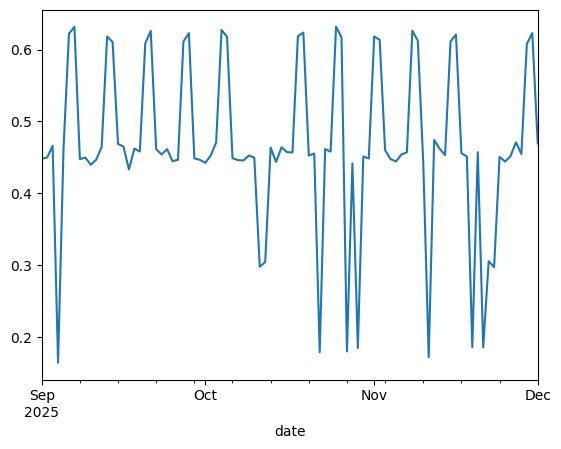

In [ ]:
# 3. 時系列の「ヨコ」と「タテ」の確認
# 10日間あるから、日が経つにつれて傾向が変わっていないか見る。

# 日別の購入率推移
df1.groupby('date')['is_purchased'].mean().plot(kind='line')

# 気温の変化や週末フラグが、ちゃんと購入率の波を作っているか確認。これがガタガタだと、時系列バリデーションが難しくなるから。

## NaNどうするか的な

In [ ]:
# 1. 欠損有無のフラグを作成
# この場合は、NaNならTrue、そうでなければFalseのフラグができる
# だがT/Fだとpycaretでplotするときに支障が出る
# df1['is_temp_nan'] = df1['current_temp'].isna()

# 1. 欠損有無のフラグを作成
# .astype(int)を足すことで、Trueが1、Falseが0の数値フラグになる
df1['is_temp_nan'] = df1['current_temp'].isna().astype(int)


# 2. フラグで集計して、購入率や他の特徴量を比較
nan_analysis = df1.groupby('is_temp_nan')[['is_purchased', 'past_latte_ratio', 'membership_years']].mean()
print(nan_analysis)


# このチェックが TabPFN / LGBM にどう活きるか

# TabPFNの場合:
# TabPFNは「欠損であること」を一つの情報としてそのまま食べてくれるから、この連鎖が強くてもわりと賢く判定してくれる。

# LGBMの場合:
# 「欠損は平均値で埋めよう」と安易に考えると、この「購入率が低い」という重要なシグナルを消しちゃうことになる。だから、「欠損フラグ列を自作してモデルに入れる」といった工夫が必要だって判断しやすい。

             is_purchased  past_latte_ratio  membership_years
is_temp_nan                                                  
0                0.465717          0.284253          2.061278
1                0.469739          0.285447          2.076965


In [ ]:
# 4. 欠損値（NaN）の「出方」のクセ
# ただの欠損じゃなくて、「特定の店舗だけ欠損している」みたいなパターンがないか見る。
# このサンプルデータではランダムにNaNを作っている。が、現実には例えばStore_Aのだけ欠損してる的なことがありがちなため。

# 欠損があるかどうかを先に判定してから、店舗ごとに合計する
# 1. まず店舗別の欠損数を算出
store_null_counts = df1.isnull().groupby(df1['store_id']).sum()

# 2. 全行（全店舗）の合計が 0 より大きいカラム（＝欠損が存在するカラム）だけに絞り込む
store_null_counts.loc[:, store_null_counts.sum() > 0]

,past_latte_ratio,past_coupon_usage_rate,current_temp
store_id,,,
Store_A,186,4034,1160
Store_B,193,3934,1199
Store_C,208,4019,1195
Store_D,198,3981,1185
Store_E,220,3830,1150
Store_F,204,4001,1206
Store_G,192,3990,1151
Store_H,186,3892,1233
Store_I,202,3908,1199


In [58]:
# # 0除算でinfやNaNになってる箇所を置換する
# df1["value2"] = df1["value2"].replace(np.inf, 0).fillna(0)

# split

In [59]:
df1.head()

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,is_temp_nan
0,ak1yw438,2025-09-01,Store_A,5.417097,0.521983,0.156813,0,0,16.571176,100.966485,117700,1,3,1,0,0
1,6d6nuthg,2025-09-01,Store_A,0.526175,0.331619,0.148589,0,0,16.571176,100.966485,117700,1,5,1,0,0
2,zjz7gdk2,2025-09-01,Store_A,3.818116,0.076237,0.009518,0,0,16.571176,100.966485,117700,0,5,0,0,0
3,mwy83qty,2025-09-01,Store_A,0.959455,0.327079,0.003839,0,0,16.571176,100.966485,117700,0,2,0,0,0
4,e8w2krli,2025-09-01,Store_A,0.500000,0.111406,0.348650,0,0,16.571176,100.966485,117700,1,6,0,0,0


In [60]:
# 日付型のカラムは、特徴量として使えるように数値型に分解する

# df1['year']        = df1['date'].dt.year          # 年（2026など）
df1['month']       = df1['date'].dt.month         # 月（1～12）
df1['day']         = df1['date'].dt.day           # 日（1～31）
df1['day_of_week'] = df1['date'].dt.dayofweek     # 曜日（0:月, 1:火 ... 6:日）
# df1['hour']        = df1['date'].dt.hour          # 時間（0～23）朝と昼の違い
# df1['is_weekend'] = (df1['date'].dt.dayofweek >= 5).astype(int) # 週末フラグを0/1の数値型にする

In [61]:
# 経過日数を用意する

# 時点カラムを整数値で表現したカラムを2種用意する
# データセット抽出時に準備済の場合はこの工程不要
# 1つめデータセット内の最古時点を1始まりとした（絶対的な）数値カラムを新設

# df1['absolute_ds'] = df1['date'].rank(method='dense').astype(int)  # 途中欠損日があるとそこ無視した連続数値になる
df1['absolute_ds'] = (df1['date'] - df1['date'].min()).dt.days + 1  # 途中欠損日があってもなんなく連続数値になる

# 2つめ介入開始時点の1時点前を基準とした（相対的な）数値カラムを新設
# 時点がすべて連続しているデータセットの場合は、基準時点からの相対的な時点番号を取得ですむが（日次での例）
# baseline_point = pd. Timestamp(' 2024-04-21°)
# df1['relative_ds'] = (df1['date'] - base_date).dt.days + 1

# 連続していない場合（control/testと同じdateで2レコードあるなど）absolute_dsから加工する
# df1['relative_ds'] = df1['absolute_ds'] - 7  # before期間が7日間で基準点が7とわかってるのでその分だけ引く

In [62]:
# # 意図した通りにナンバリングできてるかcheck
# # pd.pivot_table(df1, index=['date', 'absolute_ds', 'relative_ds'], values='customer_id', aggfunc='count')
# pd.pivot_table(df1, index=['date', 'absolute_ds'], columns='store_id', values='customer_id', aggfunc='count')

In [63]:
# 数値型の列（int系とfloat系）を抽出して、すべて float64 に統一
# intがあるとPDPのときにfuture warning出ることある

float_cols = df1.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns
df1[float_cols] = df1[float_cols].astype(float)

In [64]:
# # 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる
# df1 = df1.sort_values(by=['date', 'store_id']).reset_index(drop=True)

In [65]:
# 日付でソートされている前提
all_dates = df1['date'].unique()
n_all_days = len(all_dates)

# 分割のしきい値を決める（後半20%をテストに）
test_days = int(n_all_days * 0.2)

train_days = n_all_days - test_days  # 日数計算
test_start_date = all_dates[n_all_days - test_days]  # 日付切り出し

df_train = df1.query('date < @test_start_date')
df_test = df1.query('date >= @test_start_date')

print(f"Train: {df_train['date'].min()} ~ {df_train['date'].max()} ({train_days}days {len(df_train)}records)")
print(f"Test:  {df_test['date'].min()} ~ {df_test['date'].max()} ({test_days}days {len(df_test)}records)")

Train: 2025-09-01 00:00:00 ~ 2025-11-13 00:00:00 (74days 317442records)
Test:  2025-11-14 00:00:00 ~ 2025-12-01 00:00:00 (18days 77457records)


In [66]:
df_train.head()

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,is_temp_nan,month,day,day_of_week,absolute_ds
0,ak1yw438,2025-09-01,Store_A,5.417097,0.521983,0.156813,0.0,0.0,16.571176,100.966485,117700.0,1.0,3.0,1.0,0.0,0.0,9.0,1.0,0.0,1.0
1,6d6nuthg,2025-09-01,Store_A,0.526175,0.331619,0.148589,0.0,0.0,16.571176,100.966485,117700.0,1.0,5.0,1.0,0.0,0.0,9.0,1.0,0.0,1.0
2,zjz7gdk2,2025-09-01,Store_A,3.818116,0.076237,0.009518,0.0,0.0,16.571176,100.966485,117700.0,0.0,5.0,0.0,0.0,0.0,9.0,1.0,0.0,1.0
3,mwy83qty,2025-09-01,Store_A,0.959455,0.327079,0.003839,0.0,0.0,16.571176,100.966485,117700.0,0.0,2.0,0.0,0.0,0.0,9.0,1.0,0.0,1.0
4,e8w2krli,2025-09-01,Store_A,0.500000,0.111406,0.348650,0.0,0.0,16.571176,100.966485,117700.0,1.0,6.0,0.0,0.0,0.0,9.0,1.0,0.0,1.0


In [67]:
# # 結果変数のカラム名を変数に入れておく
# target_y_column = 'is_purchased' 

# # 特徴量から除外するリスト: 不要な特徴量および結果変数
# drop_cols = ['date', 'customer_id', target_y_column]

# # split
# X_train = df_train.drop(columns=drop_cols)
# y_train = df_train[target_y_column]

# X_val = df_val.drop(columns=drop_cols)
# y_val = df_val[target_y_column]

# # (テスト用も同様)
# X_test = df_test.drop(columns=drop_cols)
# y_test = df_test[target_y_column]

# print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


# modeling

In [68]:
# # いきなり全数だと時間かかる。とはいえ10分でおわる
# from pycaret.classification import *
# reg1 = setup(df1, target="is_purchased", session_id=1)
# base_model = compare_models(fold=5)

# setupの段階でデータを絞る（例えば3万件にする）
# reg1 = setup(df1.sample(30000, random_state=42), target="is_purchased", session_id=42)
# base_model = compare_models(fold=5)
# 一部のモデルを除外したり、重くなりやすいSVMやKNN、多層パーセプトロンを除外
# base_model = compare_models(fold=5, exclude=['svm', 'knn', 'mlp'])
# 指定もできる
# base_model = compare_models(fold=5, include=['lightgbm', 'xgboost', 'rf'])

In [69]:
# まず全モデルで比較。trainデータはサンプリング

# 時系列データなので、時系列交差検証にしたい。よってsetupの時点で指定しておく
# 時系列データにおいて、ランダムサンプリングがいいかは要検討
# ・ランダムサンプリング (frac=0.1): 季節性や長期のトレンドを薄く広く網羅できるけど、データ間の連続性は少し弱くなる。
# ・直近切り出し (tail): 今の市場環境に一番近い傾向で学習できる。

from sklearn.model_selection import TimeSeriesSplit

# 5分割の時系列交差検証を定義
ts_cv = TimeSeriesSplit(n_splits=5)  # 過去から未来へ順番に学習範囲を広げていく交差検証（Fold）

from pycaret.classification import *
# setupでその分割ルールを指定
reg1 = setup(
    # data = df_train,  # 全数
    # data = df_train.sample(30000, random_state=42)  # 30,000 sampling
    data = df_train.sample(frac=0.2, random_state=42),   # 20% sampling
    # data = df_train.tail(30000)),   # 直近3万件 sampling
    test_data = df_test,
    target = 'is_purchased',
    fold_strategy = ts_cv,  # 時系列交差検証の指定
    fold = 5,
    ignore_features = ['date', 'customer_id', 'is_temp_nan'],  # 不要な特徴量を除外
    session_id = 42,
    index = False  # indexを特徴量に使わないように
)

# setupで設定情報を保存する（reg1には前処理が終わった後のデータや各種設定値などの設定オブジェクトが入ってる）
# 後続工程ではreg1を明示的に指定せずともよい（直前に実行されたsetupの内容に従っておこなう）

,Description,Value
0,Session id,42
1,Target,is_purchased
2,Target type,Binary
3,Original data shape,"(140945, 20)"
4,Transformed data shape,"(140945, 26)"
5,Transformed train set shape,"(63488, 26)"
6,Transformed test set shape,"(77457, 26)"
7,Ignore features,3
8,Numeric features,15
9,Categorical features,1


In [70]:
# base_model = compare_models(fold=5)  # ここで指定するとsetup設定を上書きしてランダム5分割で交差検証しちゃう

# 交差検証の平均値で各モデルを比較
base_model = compare_models()  # カッコ内で出力時のsort指定できる sort='F1'など。未指定時はaccuracy順
base_model_df = pull()  # あれこれ見れるようにdataframeで受け取る

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7607,0.8401,0.7227,0.7592,0.7405,0.5187,0.5193,1.7660
lightgbm,Light Gradient Boosting Machine,0.7572,0.8375,0.7194,0.7550,0.7367,0.5117,0.5122,0.5120
lda,Linear Discriminant Analysis,0.7479,0.8284,0.7104,0.7444,0.7269,0.4931,0.4936,0.1320
ridge,Ridge Classifier,0.7478,0.0000,0.7099,0.7444,0.7267,0.4928,0.4934,0.0840
xgboost,Extreme Gradient Boosting,0.7466,0.8243,0.7125,0.7409,0.7264,0.4905,0.4909,1.2600
ada,Ada Boost Classifier,0.7458,0.8248,0.7127,0.7396,0.7259,0.4890,0.4893,0.5380
rf,Random Forest Classifier,0.7399,0.8167,0.7030,0.7349,0.7186,0.4770,0.4774,1.2760
et,Extra Trees Classifier,0.7193,0.7925,0.6856,0.7101,0.6977,0.4359,0.4361,1.0960
dt,Decision Tree Classifier,0.6608,0.6600,0.6465,0.6393,0.6429,0.3199,0.3199,0.2200
knn,K Neighbors Classifier,0.5986,0.6273,0.5520,0.5788,0.5651,0.1928,0.1930,1.3740


In [72]:
base_model_df.sort_values('F1', ascending=False)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7607,0.8401,0.7227,0.7592,0.7405,0.5187,0.5193,1.766
lightgbm,Light Gradient Boosting Machine,0.7572,0.8375,0.7194,0.7550,0.7367,0.5117,0.5122,0.512
lda,Linear Discriminant Analysis,0.7479,0.8284,0.7104,0.7444,0.7269,0.4931,0.4936,0.132
ridge,Ridge Classifier,0.7478,0.0000,0.7099,0.7444,0.7267,0.4928,0.4934,0.084
xgboost,Extreme Gradient Boosting,0.7466,0.8243,0.7125,0.7409,0.7264,0.4905,0.4909,1.260
ada,Ada Boost Classifier,0.7458,0.8248,0.7127,0.7396,0.7259,0.4890,0.4893,0.538
rf,Random Forest Classifier,0.7399,0.8167,0.7030,0.7349,0.7186,0.4770,0.4774,1.276
et,Extra Trees Classifier,0.7193,0.7925,0.6856,0.7101,0.6977,0.4359,0.4361,1.096
dt,Decision Tree Classifier,0.6608,0.6600,0.6465,0.6393,0.6429,0.3199,0.3199,0.220
knn,K Neighbors Classifier,0.5986,0.6273,0.5520,0.5788,0.5651,0.1928,0.1930,1.374


In [73]:
# gbcとlightgbmが競っているのは、データに非線形な関係（「AかつBのときだけ買う」みたいな複雑な条件）が隠れている証拠かも
# ldaやridgeが上位にいるということは、線形（単純な関係）である程度説明がつく部分が大きいことを示唆。
# 複雑なモデルで無理に精度を追うより、特徴量を整理したほうが伸びるサインかもしれない。

# 逆にqdaやsvmが最下位なのは、今回のデータ構造がそれらのロジック（二次曲線やマージン最大化）とは相性が悪かったんだなと切り捨てやすい。

In [74]:
top_model_ids = base_model_df.index[:5].tolist()
top_model_ids

['gbc', 'lightgbm', 'lda', 'ridge', 'xgboost']

## top5

In [75]:
# 今度は全件でsetupしてから、top5モデルだけで比較してみる（foldは同じく5分割の時系列交差検証）

from sklearn.model_selection import TimeSeriesSplit

# 5分割の時系列交差検証を定義
ts_cv = TimeSeriesSplit(n_splits=5)  # 過去から未来へ順番に学習範囲を広げていく交差検証（Fold）

# from pycaret.classification import *
# setupでその分割ルールを指定
reg1 = setup(
    data = df_train,  # 全数
    # data = df_train.sample(30000, random_state=42)  # 30,000 sampling
    # data = df_train.sample(frac=0.2, random_state=42),   # 20% sampling
    test_data = df_test,
    target = 'is_purchased',
    fold_strategy = ts_cv,  # 時系列交差検証の指定
    fold = 5,
    ignore_features = ['date', 'customer_id', 'is_temp_nan'],  # 不要な特徴量を除外
    session_id = 42,
    index = False  # indexを特徴量に使わないように
)

,Description,Value
0,Session id,42
1,Target,is_purchased
2,Target type,Binary
3,Original data shape,"(394899, 20)"
4,Transformed data shape,"(394899, 26)"
5,Transformed train set shape,"(317442, 26)"
6,Transformed test set shape,"(77457, 26)"
7,Ignore features,3
8,Numeric features,15
9,Categorical features,1


In [76]:
# top5のみで
best_models_full = compare_models(include = top_model_ids)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7592,0.8384,0.7311,0.7525,0.7416,0.5145,0.5148,0.8540
gbc,Gradient Boosting Classifier,0.7587,0.8380,0.7317,0.7510,0.7412,0.5136,0.5138,8.9960
xgboost,Extreme Gradient Boosting,0.7551,0.8332,0.7138,0.7550,0.7336,0.5050,0.5059,7.0780
ridge,Ridge Classifier,0.7476,0.0000,0.7107,0.7436,0.7266,0.4900,0.4906,0.2440
lda,Linear Discriminant Analysis,0.7475,0.8261,0.7114,0.7432,0.7268,0.4900,0.4906,0.4260


In [77]:
# 上位3つ lightgbm, gbc, xgboost のスコアが近しい。このデータにおける「正解の限界値」に近づいている証拠ともいえそうか。
# 線形モデル（lda, ridge）の健闘。モデルの解釈性（なぜその予測になったか）を重視するなら検討余地あるが、精度優先ならLGBMだろう

## create model

In [78]:
# 1. LightGBMモデルを確定させる
# 交差検証5回実行した結果の平均値と標準偏差が出力される（上で見てた数値）
lgbm_model = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7477,0.8275,0.7353,0.7584,0.7467,0.4954,0.4957
1,0.7527,0.8340,0.7474,0.7589,0.7531,0.5054,0.5054
2,0.7532,0.8299,0.7321,0.7285,0.7303,0.5028,0.5028
3,0.7802,0.8570,0.7107,0.7551,0.7322,0.5461,0.5468
4,0.7625,0.8435,0.7301,0.7615,0.7455,0.5230,0.5234
Mean,0.7592,0.8384,0.7311,0.7525,0.7416,0.5145,0.5148
Std,0.0115,0.0108,0.0119,0.0122,0.0088,0.0182,0.0184


In [79]:
lgbm_model 

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [80]:
plot_model(lgbm_model, plot='parameter')

,Parameters
boosting_type,gbdt
class_weight,None
colsample_bytree,1.0
importance_type,split
learning_rate,0.1
max_depth,-1
min_child_samples,20
min_child_weight,0.001
min_split_gain,0.0
n_estimators,100


In [81]:
# 2. ハイパーパラメータを自動で最適化する
# n_iterはグリッドサーチの試行回数（デフォルトは10）、optimizeは最適化したい指標（デフォルトはaccuracy）
tuned_lgbm = tune_model(lgbm_model, n_iter=50, optimize="F1")

# 先ほど同様に、交差検証5回実行した結果の平均値と標準偏差が出力される
# あくまで今ある特徴量の中でチューニングする。のでスコアが伸び悩むようなら、特徴量エンジニアリングやアンサンブルやったがいいかも（あるいは初期設定時点で十分優秀でそもそも伸びしろなかった）

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7485,0.8282,0.7401,0.7572,0.7486,0.4971,0.4972
1,0.7533,0.8340,0.7469,0.7601,0.7534,0.5066,0.5067
2,0.7573,0.8331,0.7249,0.7385,0.7316,0.5101,0.5101
3,0.7789,0.8568,0.7062,0.7550,0.7298,0.5430,0.5438
4,0.7613,0.8426,0.7227,0.7636,0.7426,0.5204,0.5211
Mean,0.7598,0.8389,0.7282,0.7549,0.7412,0.5154,0.5158
Std,0.0104,0.0100,0.0143,0.0087,0.0093,0.0157,0.0160


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [82]:
tuned_lgbm

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [83]:
plot_model(tuned_lgbm, plot='parameter')

,Parameters
boosting_type,gbdt
class_weight,None
colsample_bytree,1.0
importance_type,split
learning_rate,0.1
max_depth,-1
min_child_samples,20
min_child_weight,0.001
min_split_gain,0.0
n_estimators,100


## evaluation

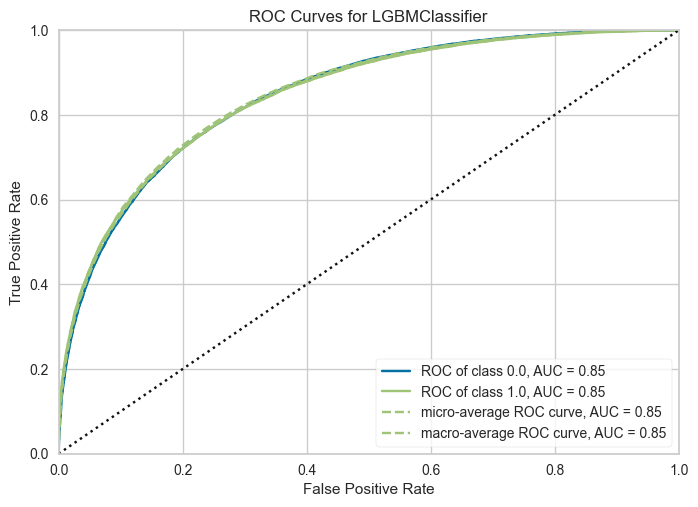

In [84]:
plot_model(tuned_lgbm, plot="auc")

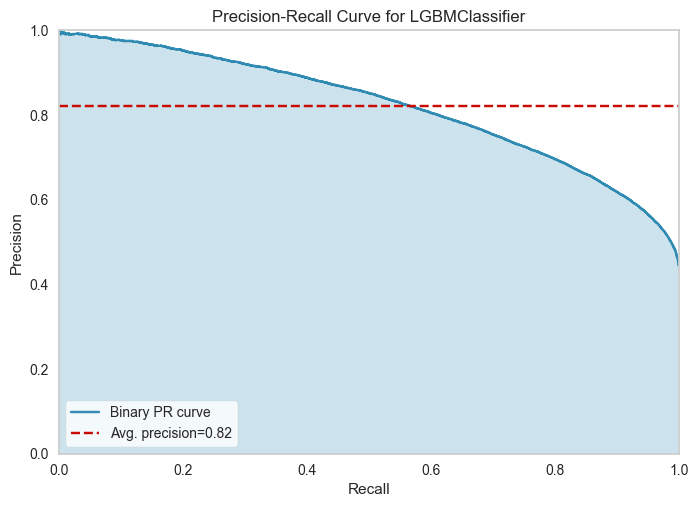

In [85]:
plot_model(tuned_lgbm, plot="pr")

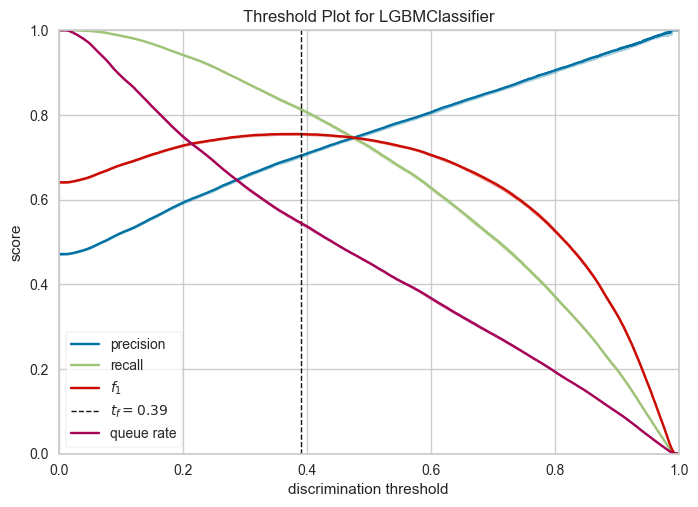

In [86]:
# threhold（しきい値）を変えた時に、各指標がどう動くかを可視化
plot_model(tuned_lgbm, plot='threshold')

# おすすめthresholdは、optimizeで指定した指標（F1値）が最大になる0.38
# PrecisionとRecallは、threshold0.5あたりで交差する。PrecisionとRecallを等価にみなすなら、0.5付近にする選択もあり。

# Queue Rate（紫）: thresholdを0.38にしたとき約0.55とは、全データのうち約55%を陽性（1）と判定して施策対象にできるとの意味。多すぎて対応しきれないなどの制約がある場合は、thresholdを右側にずらして対応件数を絞る判断の目安に。あるいはPrecisionやRecallのどちらを重視するかに応じて判断するのもあり。

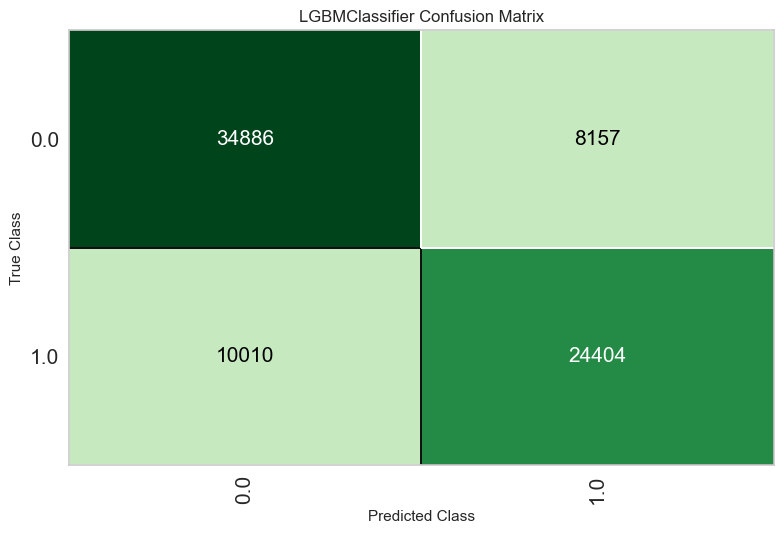

In [87]:
plot_model(tuned_lgbm, plot="confusion_matrix")

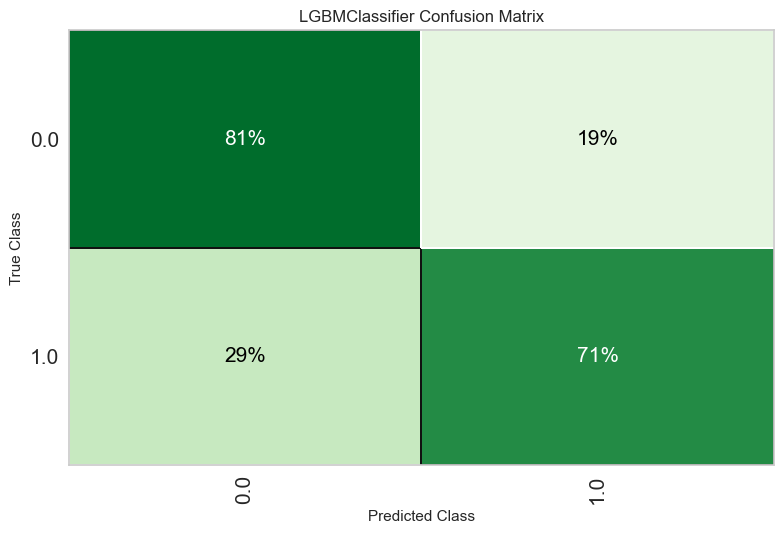

In [88]:
# Yellowbrickの引数設定
plot_model(tuned_lgbm, plot='confusion_matrix', plot_kwargs={'percent': True})

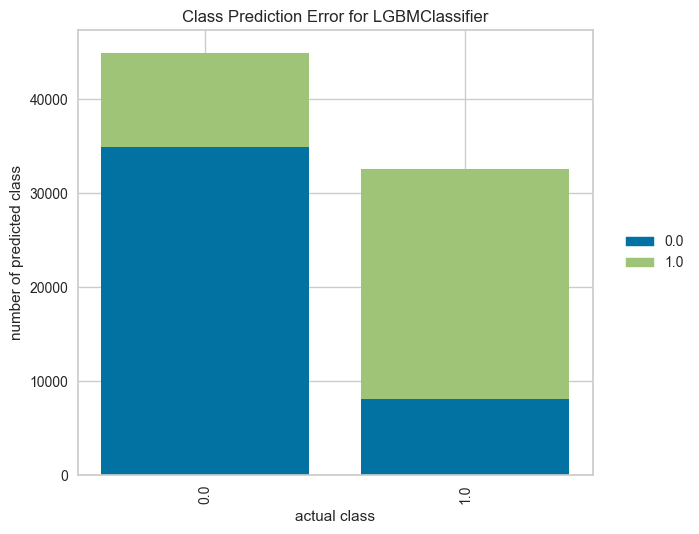

In [89]:
plot_model(tuned_lgbm, plot="error")
# 情報として混同行列と同じ。混同行列での色の濃さを高さで表現している。
# グラフの目盛はどうも大雑把らしいので混同行列の値とちょっとぐらい違っても気にしないでよい。

In [90]:
# テストデータでの予測結果を取得
pred_holdout = predict_model(tuned_lgbm)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.7655,0.8466,0.7091,0.7495,0.7287,0.5224,0.5231


In [ ]:
# ただしこの場合、prediction_scoreに格納されてる値は、そのラベルだと判定した確率
# なので、prediction_label=1ならprediction_scoreを、label=0なら1-prediction_scoreを格納したカラムを新設しておく
# 'pos_score' という名前で、1である確率を統一して格納する
pred_holdout['pos_score'] = pred_holdout.apply(
    lambda x: x['prediction_score'] if x['prediction_label'] == 1 else 1 - x['prediction_score'],
    axis=1
)

pred_holdout.head()

,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_holiday,month,day,day_of_week,absolute_ds,is_purchased,prediction_label,prediction_score,pos_score
317442,Store_A,0.500000,0.231377,0.601314,0.0,0.0,19.705204,112.491768,117947.0,0.0,8.0,0.0,11.0,14.0,4.0,75.0,1.0,0,0.7161,0.2839
317443,Store_A,1.453212,0.183694,0.138434,0.0,0.0,19.705204,112.491768,117947.0,0.0,5.0,0.0,11.0,14.0,4.0,75.0,0.0,0,0.8011,0.1989
317444,Store_A,2.762920,0.093384,0.195006,0.0,0.0,19.705204,112.491768,117947.0,0.0,5.0,0.0,11.0,14.0,4.0,75.0,0.0,0,0.8896,0.1104
317445,Store_A,0.995742,0.313460,0.426811,0.0,0.0,19.705204,112.491768,117947.0,0.0,5.0,0.0,11.0,14.0,4.0,75.0,0.0,0,0.6441,0.3559
317446,Store_A,0.500000,0.259202,0.067040,0.0,0.0,19.705204,112.491768,117947.0,1.0,3.0,0.0,11.0,14.0,4.0,75.0,0.0,0,0.6154,0.3846


In [92]:
y_val = pred_holdout['is_purchased'].values
y_pred_val = pred_holdout['pos_score'].values
y_class_pred = (y_pred_val > 0.5).astype(int)

In [93]:

# # 混同行列の数値を算出
# cm = confusion_matrix(pred_holdout['is_purchased'], pred_holdout['prediction_label'])
# print(cm)

In [94]:
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

def evaluate_model_performance(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    
    # 1. 各種スコア
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"PR-AUC : {average_precision_score(y_true, y_prob):.4f}")
    print("-" * 30)
    print(classification_report(y_true, y_pred))
    
    # 2. 混合行列
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].grid(False)  # SeabornやPyCaretが設定したGrid設定が残ってて余分なGridが表示されるのをいったん消す処置
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], cmap='Blues')
    axes[0].set_title("Confusion Matrix")
    
    # 3. 確率の分布
    axes[1].hist(y_prob[y_true == 0], bins=50, alpha=0.5, label='Actual: 0', color='blue')
    axes[1].hist(y_prob[y_true == 1], bins=50, alpha=0.5, label='Actual: 1', color='red')
    axes[1].set_title("Prediction Probability Distribution")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

ROC-AUC: 0.8466
PR-AUC : 0.8217
------------------------------
              precision    recall  f1-score   support

         0.0       0.78      0.81      0.79     43043
         1.0       0.75      0.71      0.73     34414

    accuracy                           0.77     77457
   macro avg       0.76      0.76      0.76     77457
weighted avg       0.76      0.77      0.76     77457



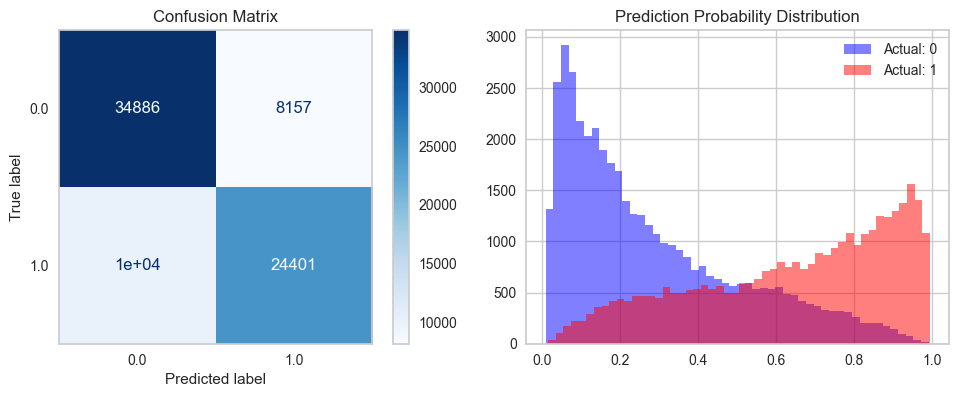

In [95]:
evaluate_model_performance(y_val, y_pred_val, threshold=0.5)

In [ ]:
# plot_model(tuned_lgbm, plot="rfe")

# # モデルに使う特徴量の数とモデルのスコアの関係を表している。ii黒の点線で示す特徴量数でモデルのスコアが最大となる。特徴量はあとで計算するFeature Importanceに基づいて順位が高いものから選択される

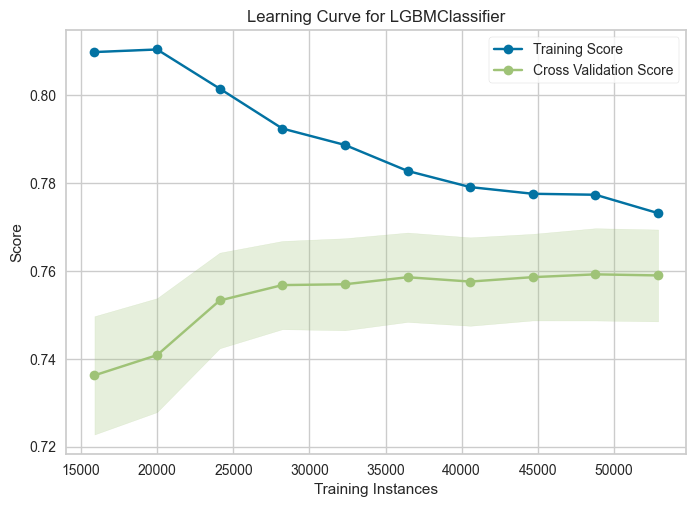

In [97]:
# 可視化　引数plot=learningで学習曲線
plot_model(tuned_lgbm, plot="learning")

# 2本の線の間隔（過学習チェック）
# Training Score（青）: 学習データでの予測精度。Cross Validation Score（緑）: 検証データでの予測精度。塗りつぶしは標準偏差。
# 間隔が狭まっているほど、過学習せずに未知データにも対応できてるという意味。

# 右端の方で緑線が横ばい（収束してる）。今の特徴量のままだとデータを増やしても劇的な精度向上は見込めない（今の特徴量の組み合わせで到達できる限界点が見えてそう）を示してる。
# 今以上の精度を目指すなら、データ件数を増やす努力よりも、新しい特徴量（前回来店からの経過日数とか）を追加する方が得策っぽい。
# もし右端がまだグイグイ上に向かっていたら、もっとデータを集めてサインともいえる。

# どちらもスコアが低いのは学習不足かもなのでパラメータを増やす。trainだけ高いのは過学習気味なのでパラメータ数を減らすなど。

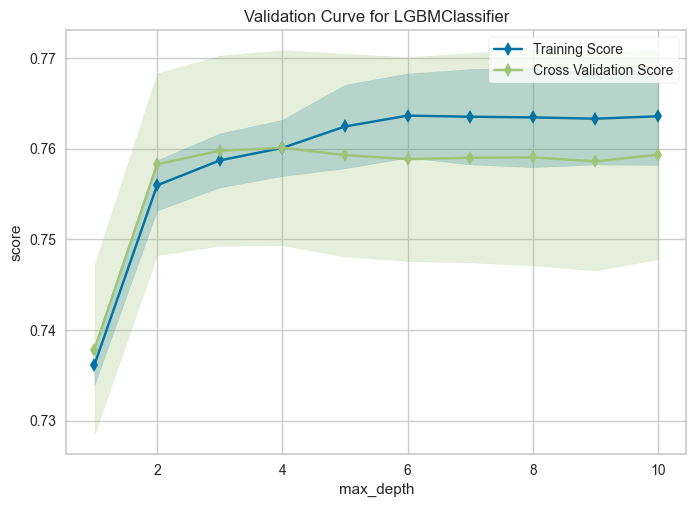

In [98]:
# 可視化　引数plot=vcで 検証曲線
plot_model(tuned_lgbm, plot="vc")

# 見た目はLearning Curveと似てるが目的が異なる。特定のハイパーパラメータ（max_depth）をいじると、scoreがどう変わるかを見ている。

# 1. max_depth（木の深さ）との関係
# 横軸のmax_depthは決定木の「階層をどこまで深くするか」を表してる。
# 左側（浅い）： 木が単純すぎて、複雑なパターンを捉えきれていない状態（未学習）。
# 右側（深い）： 木が複雑になり、細かいルールまで覚えようとしている状態。

# 2. 2本の線の重なり具合
# 青（学習用）と緑（検証用）がピッタリ重なって右肩上がりに進み、その後一緒に横ばいになっている。過学習してなさそう。
# もし過学習が起きてるなら、深くなるにつれて青だけが上がり続け、緑が下がっていく。だがそうなってない（汎用性を保ててる）。

# 3. どこが最適かの判断
# max_depth=3くらいまでは急激に精度が上がっているけど、5以降はほとんどスコアが変わっていない。このモデルは深さ5くらいあれば十分で、それ以上に深くしても計算時間がかかるだけで意味がなさそう。

# PFI permutation feature importance

In [99]:
get_config('X_train_transformed')

,store_id_Store_A,store_id_Store_B,store_id_Store_C,store_id_Store_D,store_id_Store_E,store_id_Store_F,store_id_Store_G,store_id_Store_H,store_id_Store_I,store_id_Store_J,...,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_holiday,month,day,day_of_week,absolute_ds
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.571177,100.966484,117700.0,1.0,3.0,0.0,9.0,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.571177,100.966484,117700.0,1.0,5.0,0.0,9.0,1.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.571177,100.966484,117700.0,0.0,5.0,0.0,9.0,1.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.571177,100.966484,117700.0,0.0,2.0,0.0,9.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.571177,100.966484,117700.0,1.0,6.0,0.0,9.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,18.186958,116.056328,129160.0,0.0,5.0,0.0,11.0,13.0,3.0,74.0
317438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,18.186958,116.056328,129160.0,0.0,8.0,0.0,11.0,13.0,3.0,74.0
317439,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,18.186958,116.056328,129160.0,0.0,3.0,0.0,11.0,13.0,3.0,74.0
317440,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,18.186958,116.056328,129160.0,1.0,5.0,0.0,11.0,13.0,3.0,74.0


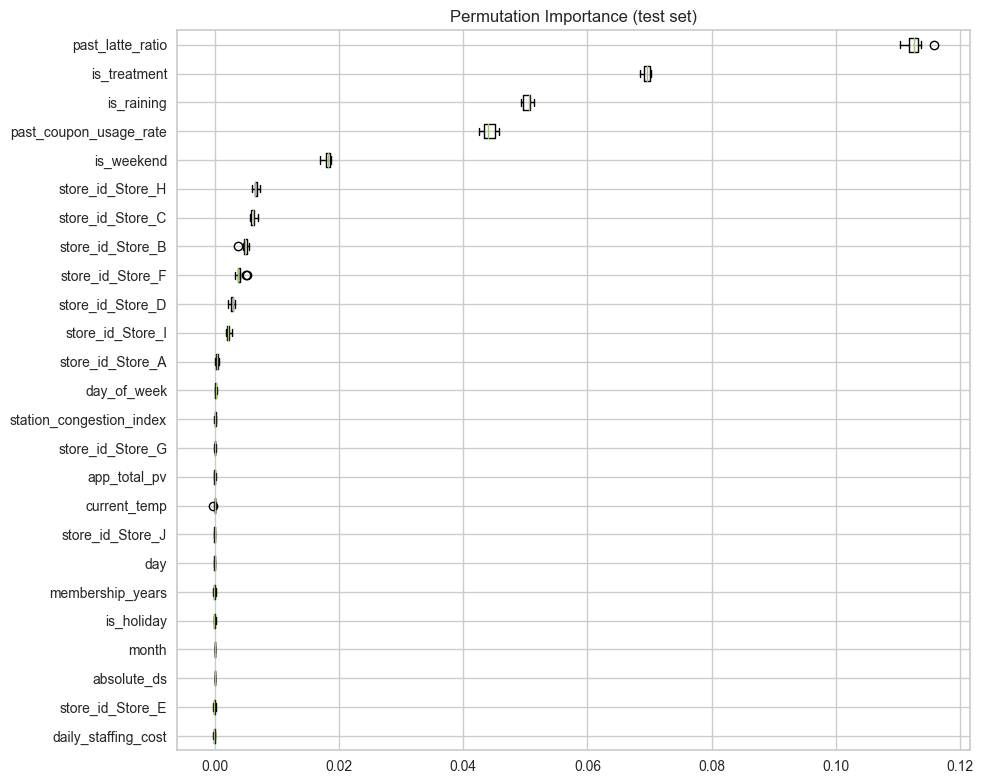

In [100]:
from sklearn.inspection import permutation_importance

# PyCaretの現在のホールドアウトデータ（検証データ）を取得
X_test = get_config('X_test_transformed')
y_test = get_config('y_test')

# PFIの計算（n_repeatsは試行回数。とりあえず5〜10くらいでOK）
result = permutation_importance(tuned_lgbm, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# 可視化
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 8))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance (test set)")
plt.tight_layout()
plt.show()

In [ ]:
# PFI
# その変数を壊したときに、どれだけ精度が落ちるか。	
# 弱点として、特徴量同士に強い相関がある場合、片方を壊してももう一方が補ってしまうため、重要度が低く出ることがある。

# 1. PFIならではの強み
# SHAPは「ある特徴量が予測値をどれだけ動かしたか（寄与度）」を見るのに対して、PFIは**「その特徴量が予測の『正解』にどれだけ貢献したか」**を見る。
# 「正解」との紐付け：
# SHAPはあくまで「モデルの出力」を説明するだけ。もしモデルが間違った学習をしていても、その通りに説明しちゃう。一方でPFIは「評価指標（F1やAUCなど）の低下」を見るから、より「ビジネス上の成功（予測の的中）に直結している変数」がわかる。
# 計算の速さと手軽さ：
# SHAP（特にKernelSHAPなど）は計算がめちゃくちゃ重いことがあるけど、PFIはデータをシャッフルして予測を回すだけだから、変数が多い時でもサクッと実行できるのが強み。

# 2. SHAPではわからないPFIの特徴
# 「過学習」への感度：
# もしある変数が「学習データではすごく効いているけど、テストデータ（PFI）では全然順位が低い」という場合、その変数が原因で過学習している可能性に気づける。
# 「壊した時のインパクト」：
# PFIは「もしこのデータが欠損したり、ノイズだらけになったら、どれだけ予測がボロボロになるか」というリスク管理的な視点を教えてくれる。

# 3. PFIの問題点（注意点）
# PFIは「多重共線性（相関が強い変数）」に弱い。
# 相関がある場合：
# 例えば「気温」と「アイスの売上」が強い相関を持っていたとする。片方をシャッフルして壊しても、モデルがもう片方の変数を使って予測を補完できてしまう場合、PFIでは「どちらも重要ではない」と判定されちゃうことがある。
# 非現実的なデータの生成：
# データをランダムにシャッフルするから、「雪が降っているのに気温35度」みたいな、現実にはあり得ないデータの組み合わせでモデルを評価してしまうことがある。これによって、モデルが混乱して変な評価を下しちゃうリスクがある。

# feature importance

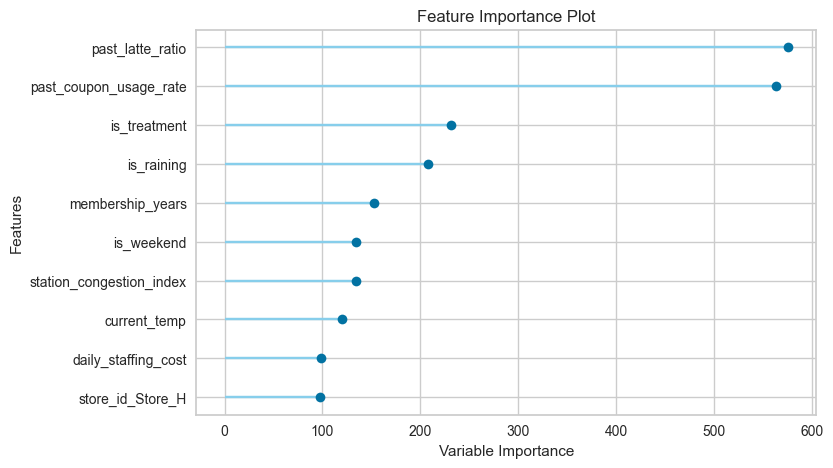

In [102]:
# 可視化　引数plot = feature　で特徴重要度プロット
# split 各特徴量が決定木の中で分割に使われた回数が表示されてる（gainではない）
plot_model(tuned_lgbm, plot="feature")  # top10
# plot_model(tuned_lgbm, plot="feature_all")

In [ ]:

# 1. 既にモデル単体なので、そのまま名前と重要度を取る
# LightGBMの場合、モデルの中に feature_name_ という属性がある
final_feature_names = tuned_lgbm.feature_name_
importance_values = tuned_lgbm.feature_importances_

# 2. DataFrameにまとめる
importance_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False)

# 3. 正規化（シェア算出）
importance_df['Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()

print(importance_df)

                     Feature  Importance  Normalized
11          past_latte_ratio         576    0.192000
12    past_coupon_usage_rate         564    0.188000
18              is_treatment         231    0.077000
13                is_raining         208    0.069333
10          membership_years         153    0.051000
16  station_congestion_index         134    0.044667
14                is_weekend         134    0.044667
15              current_temp         120    0.040000
17       daily_staffing_cost          99    0.033000
7           store_id_Store_H          97    0.032333
2           store_id_Store_C          95    0.031667
1           store_id_Store_B          93    0.031000
5           store_id_Store_F          72    0.024000
19              app_total_pv          71    0.023667
3           store_id_Store_D          62    0.020667
22                       day          61    0.020333
24               absolute_ds          51    0.017000
8           store_id_Store_I          49    0.

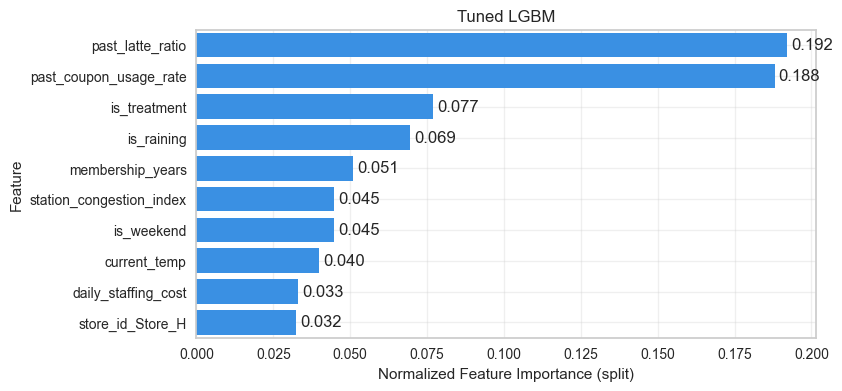

In [104]:
plt.figure(figsize=(8, 4))
sns.barplot(x='Normalized', y='Feature', data=importance_df.head(10), color='dodgerblue')
plt.title('Tuned LGBM')
plt.xlabel('Normalized Feature Importance (split)')
plt.grid(True, alpha=0.3)
for i in plt.gca().containers:
    plt.gca().bar_label(i, padding=3, fmt='{:,.3f}')
plt.show()

# shap

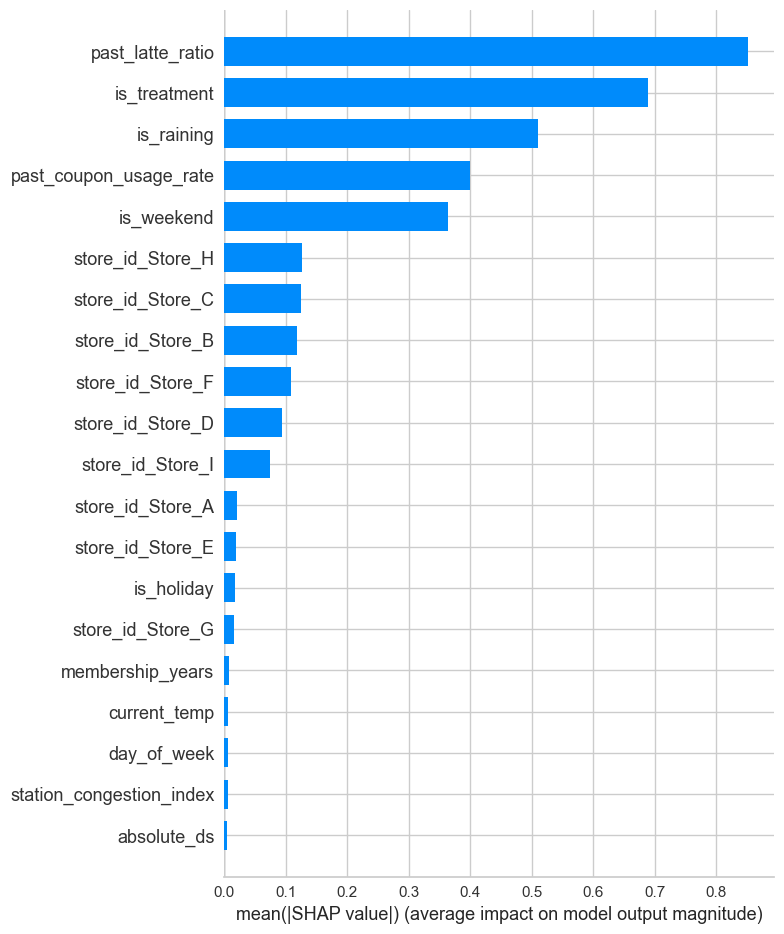

In [105]:
interpret_model(tuned_lgbm, plot_type='bar')

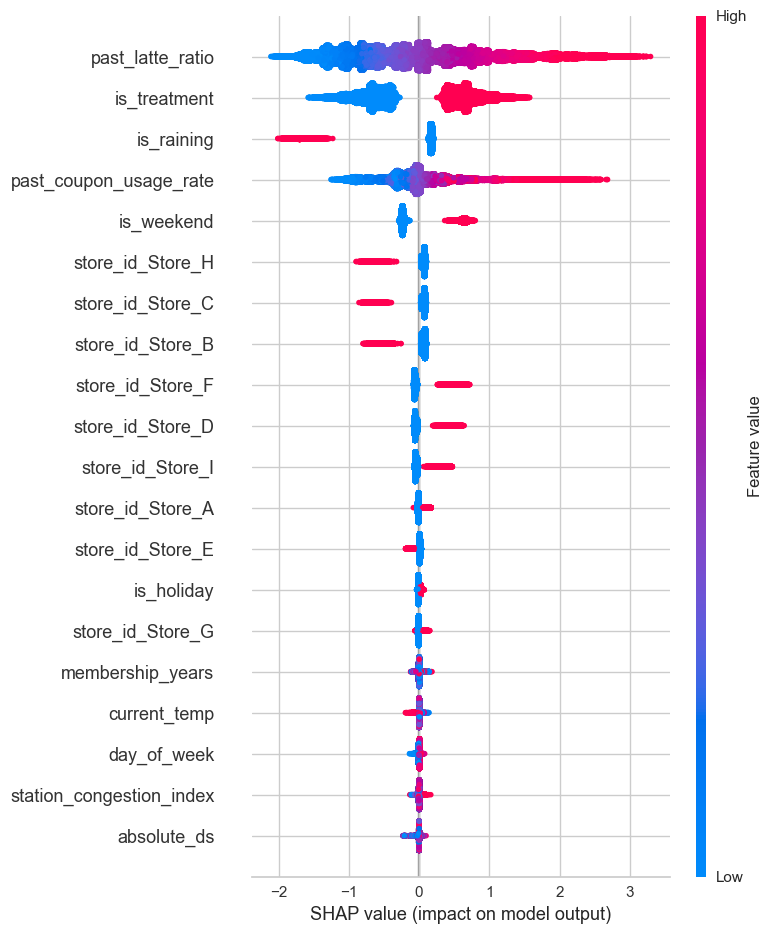

In [106]:
# SHAP beeswarm
interpret_model(tuned_lgbm)

# past_latte_ratioの広がり
# 右にも左にも大きく広がっているから、ラテ派かどうかが予測を左右する最大の分岐点になっているのがわかる。

# is_treatment（施策）のポジティブさ
# 右側に赤い点が固まっているから、施策を打てばしっかりポジティブに反応することがわかる。

# is_raining（雨）の逆転現象
# 左側に赤い点（High = 雨が降っている）が固まってる。雨が降ると予測値を大きく引き下げるというマイナス影響を示してる。

In [107]:
# 実行できなかったものたち

In [108]:
# interpret_model(tuned_lgbm, plot="reason", observation=317442)
# IndexError: single positional indexer is out-of-bounds

# interpret_model(tuned_lgbm, plot="reason", observation=0)
# IndexError: invalid index to scalar variable.

In [109]:
# 例えば 'past_latte_ratio' がどう効いているか見たいとき
# interpret_model(tuned_lgbm, plot='correlation', feature='past_latte_ratio', use_train_data=True)
# IndexError: index 11 is out of bounds for axis 1 with size 1

In [110]:
# interpret_model(tuned_lgbm, plot="pfi")
# ModuleNotFoundError: 
# 'interpret_community' is a soft dependency and not included in the pycaret installation. Please run: `pip install interpret-community` to install.

# interpret_model(tuned_lgbm, plot="pdp")
# ValueError: could not convert string to float: 'False'

# interpret_model(tuned_lgbm, plot="msa")
# ValueError: could not convert string to float: 'False'

In [111]:
interpret_model(tuned_lgbm, plot="msa")
# ValueError: could not convert string to float: 'False'

# SHAP2


In [112]:
df_test.head()

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,is_temp_nan,month,day,day_of_week,absolute_ds
317442,t3k1y6a0,2025-11-14,Store_A,0.500000,0.231377,0.601314,0.0,0.0,19.705204,112.491769,117947.0,0.0,8.0,1.0,0.0,0.0,11.0,14.0,4.0,75.0
317443,i8spctx6,2025-11-14,Store_A,1.453212,0.183694,0.138434,0.0,0.0,19.705204,112.491769,117947.0,0.0,5.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0
317444,3sqs1zzw,2025-11-14,Store_A,2.762920,0.093384,0.195006,0.0,0.0,19.705204,112.491769,117947.0,0.0,5.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0
317445,50txl866,2025-11-14,Store_A,0.995742,0.313460,0.426811,0.0,0.0,19.705204,112.491769,117947.0,0.0,5.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0
317446,vms9lsli,2025-11-14,Store_A,0.500000,0.259202,0.067040,0.0,0.0,19.705204,112.491769,117947.0,1.0,3.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0


In [ ]:

# 1. データを綺麗にして取り出す
# X_test = get_config('X_test').reset_index(drop=True)
# X_test = get_config('X_test_transformed').reset_index(drop=True)
X_test = get_config('X_test_transformed')

# # 1. SHAP値を計算するオブジェクト（Explainer）を作成
# # modelはハイパラチューニング済みのを指定
explainer = shap.TreeExplainer(tuned_lgbm, feature_perturbation="tree_path_dependent")

# X_testを渡す
# サンプリングして渡してもいい
# X_test_sample = X_test.sample(n=1000, random_state=42)
shap_values_obj = explainer(X_test)

In [114]:
X_test.head()

,store_id_Store_A,store_id_Store_B,store_id_Store_C,store_id_Store_D,store_id_Store_E,store_id_Store_F,store_id_Store_G,store_id_Store_H,store_id_Store_I,store_id_Store_J,...,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_holiday,month,day,day_of_week,absolute_ds
317442,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.705204,112.491768,117947.0,0.0,8.0,0.0,11.0,14.0,4.0,75.0
317443,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.705204,112.491768,117947.0,0.0,5.0,0.0,11.0,14.0,4.0,75.0
317444,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.705204,112.491768,117947.0,0.0,5.0,0.0,11.0,14.0,4.0,75.0
317445,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.705204,112.491768,117947.0,0.0,5.0,0.0,11.0,14.0,4.0,75.0
317446,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.705204,112.491768,117947.0,1.0,3.0,0.0,11.0,14.0,4.0,75.0


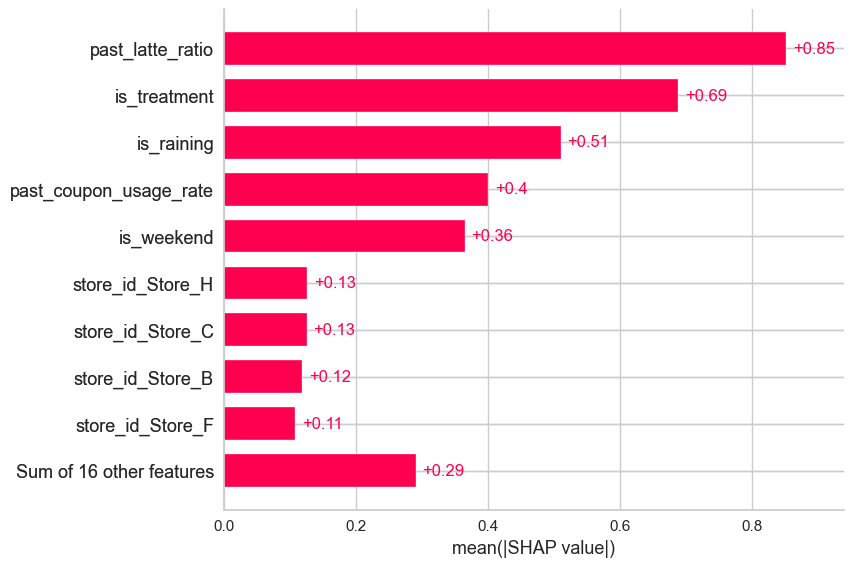

In [115]:
shap.plots.bar(shap_values_obj, max_display=10)

In [116]:
# 平均絶対SHAP値を計算してソートして表示
# SHAP値平均を算出（して値だけあれば事足りるとき用）

# features = X_test.columns.tolist()
features = tuned_lgbm.feature_name_

mean_abs_shap = np.abs(shap_values_obj.values).mean(axis=0)
df_shap_importance = pd.DataFrame({
    'feature': features, 
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print(df_shap_importance.head(20).round(2))

                     feature  mean_abs_shap
11          past_latte_ratio           0.85
18              is_treatment           0.69
13                is_raining           0.51
12    past_coupon_usage_rate           0.40
14                is_weekend           0.36
7           store_id_Store_H           0.13
2           store_id_Store_C           0.13
1           store_id_Store_B           0.12
5           store_id_Store_F           0.11
3           store_id_Store_D           0.09
8           store_id_Store_I           0.08
0           store_id_Store_A           0.02
4           store_id_Store_E           0.02
20                is_holiday           0.02
6           store_id_Store_G           0.02
10          membership_years           0.01
15              current_temp           0.01
23               day_of_week           0.01
16  station_congestion_index           0.01
24               absolute_ds           0.01


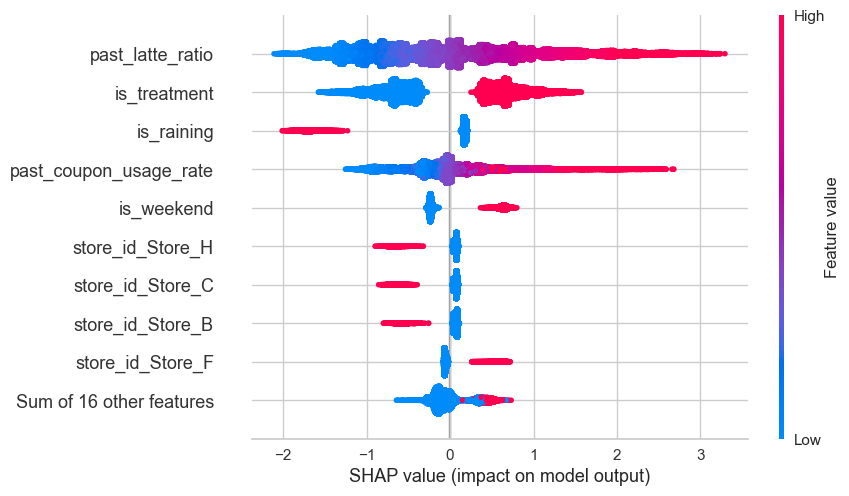

In [117]:
shap.plots.beeswarm(shap_values_obj)

In [118]:
df_test.head()

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,is_temp_nan,month,day,day_of_week,absolute_ds
317442,t3k1y6a0,2025-11-14,Store_A,0.500000,0.231377,0.601314,0.0,0.0,19.705204,112.491769,117947.0,0.0,8.0,1.0,0.0,0.0,11.0,14.0,4.0,75.0
317443,i8spctx6,2025-11-14,Store_A,1.453212,0.183694,0.138434,0.0,0.0,19.705204,112.491769,117947.0,0.0,5.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0
317444,3sqs1zzw,2025-11-14,Store_A,2.762920,0.093384,0.195006,0.0,0.0,19.705204,112.491769,117947.0,0.0,5.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0
317445,50txl866,2025-11-14,Store_A,0.995742,0.313460,0.426811,0.0,0.0,19.705204,112.491769,117947.0,0.0,5.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0
317446,vms9lsli,2025-11-14,Store_A,0.500000,0.259202,0.067040,0.0,0.0,19.705204,112.491769,117947.0,1.0,3.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0


In [119]:
shap_values_obj.shape

(77457, 25)

In [120]:
df_test.insert(0, 'seq_no', range(len(df_test)))

In [121]:
df_test.head()

,seq_no,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,...,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,is_temp_nan,month,day,day_of_week,absolute_ds
317442,0,t3k1y6a0,2025-11-14,Store_A,0.500000,0.231377,0.601314,0.0,0.0,19.705204,...,117947.0,0.0,8.0,1.0,0.0,0.0,11.0,14.0,4.0,75.0
317443,1,i8spctx6,2025-11-14,Store_A,1.453212,0.183694,0.138434,0.0,0.0,19.705204,...,117947.0,0.0,5.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0
317444,2,3sqs1zzw,2025-11-14,Store_A,2.762920,0.093384,0.195006,0.0,0.0,19.705204,...,117947.0,0.0,5.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0
317445,3,50txl866,2025-11-14,Store_A,0.995742,0.313460,0.426811,0.0,0.0,19.705204,...,117947.0,0.0,5.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0
317446,4,vms9lsli,2025-11-14,Store_A,0.500000,0.259202,0.067040,0.0,0.0,19.705204,...,117947.0,1.0,3.0,0.0,0.0,0.0,11.0,14.0,4.0,75.0


In [122]:
df_test.tail()

,seq_no,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,...,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,is_temp_nan,month,day,day_of_week,absolute_ds
394894,77452,r1pbt3ia,2025-12-01,Store_J,0.687748,0.411578,0.274403,0.0,0.0,16.552394,...,114414.0,0.0,6.0,1.0,0.0,0.0,12.0,1.0,0.0,92.0
394895,77453,xx98yuo7,2025-12-01,Store_J,0.500000,0.258778,0.129266,0.0,0.0,16.552394,...,114414.0,1.0,4.0,1.0,0.0,0.0,12.0,1.0,0.0,92.0
394896,77454,9418q3iw,2025-12-01,Store_J,6.931259,0.509925,0.162800,0.0,0.0,16.552394,...,114414.0,0.0,6.0,0.0,0.0,0.0,12.0,1.0,0.0,92.0
394897,77455,bxjhec63,2025-12-01,Store_J,1.541935,0.192038,0.160255,0.0,0.0,16.552394,...,114414.0,1.0,5.0,0.0,0.0,0.0,12.0,1.0,0.0,92.0
394898,77456,hfzd3800,2025-12-01,Store_J,0.966106,0.380918,0.332912,0.0,0.0,16.552394,...,114414.0,0.0,3.0,1.0,0.0,0.0,12.0,1.0,0.0,92.0


Index 317445 は、dataframeの 3 行目でした。


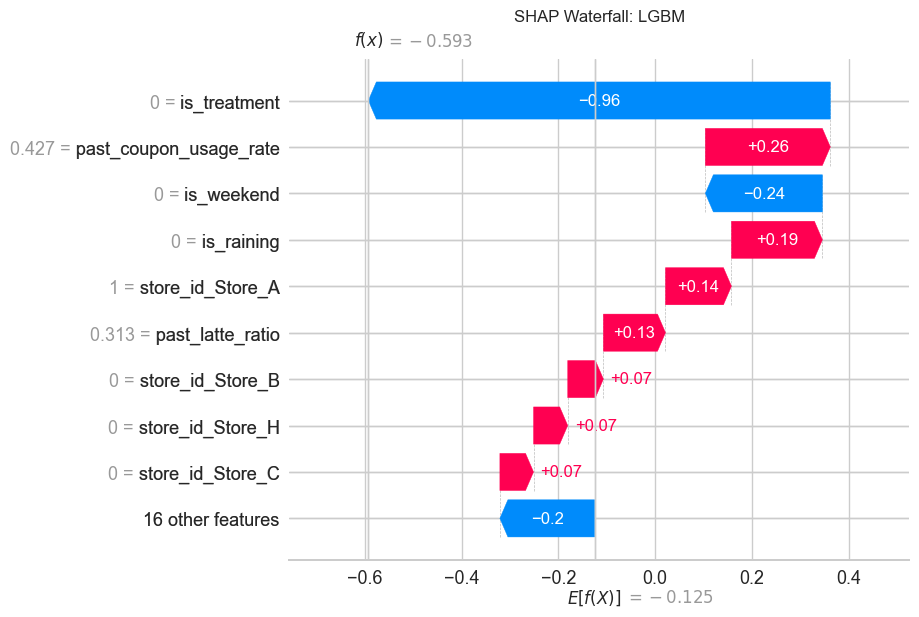

In [ ]:
# waterfallをプロット
# ・

# 1. 狙いたいインデックス（顧客IDなど）を指定
# target_id = 317442 # これがもともとのDataFrameのindexだとする
target_id = 317445 # これがもともとのDataFrameのindexだとする
# target_id = 0 # これがDataFrameのindexだとする

# 2. df1 のインデックスから「行番号（0からの連番）」を取得
# target_row_num = df1.index.get_loc(target_id)
# 2. df_testのindexを指定して、0始まりの連番カラムの値を取得することで、shap_values_objのindexに合わせにいっている
# target_row_num = df_test.loc[target_id, 'seq_no']  # これでも実行できる（atの方が単体感はある）
target_row_num = df_test.at[target_id, 'seq_no']
print(f"Index {target_id} は、dataframeの {target_row_num} 行目でした。")

shap.plots.waterfall(shap_values_obj[target_row_num], max_display=10, show=False)
plt.title(f"SHAP Waterfall: LGBM")
plt.show()

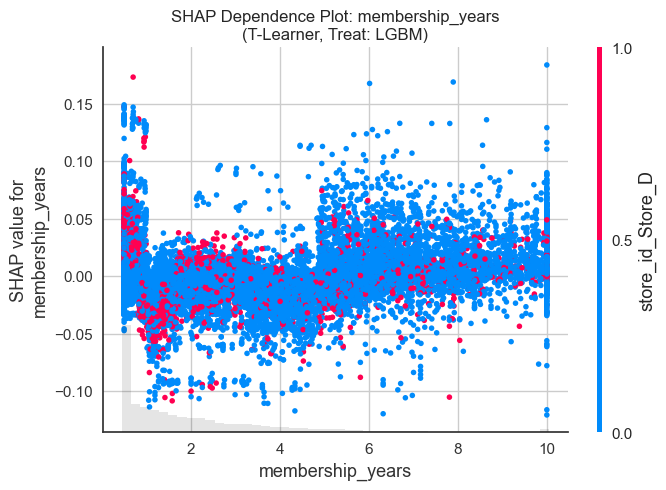

In [124]:
shap_target_feature = 'membership_years'
# shap_target_feature = 'past_coupon_usage_rate'

# Scatterプロットを実行（特定の変数を指定）色分けは自動で決まる
shap.plots.scatter(shap_values_obj[:, shap_target_feature], color=shap_values_obj, show=False)
plt.title(f'SHAP Dependence Plot: {shap_target_feature}\n(T-Learner, Treat: LGBM)')
plt.show()


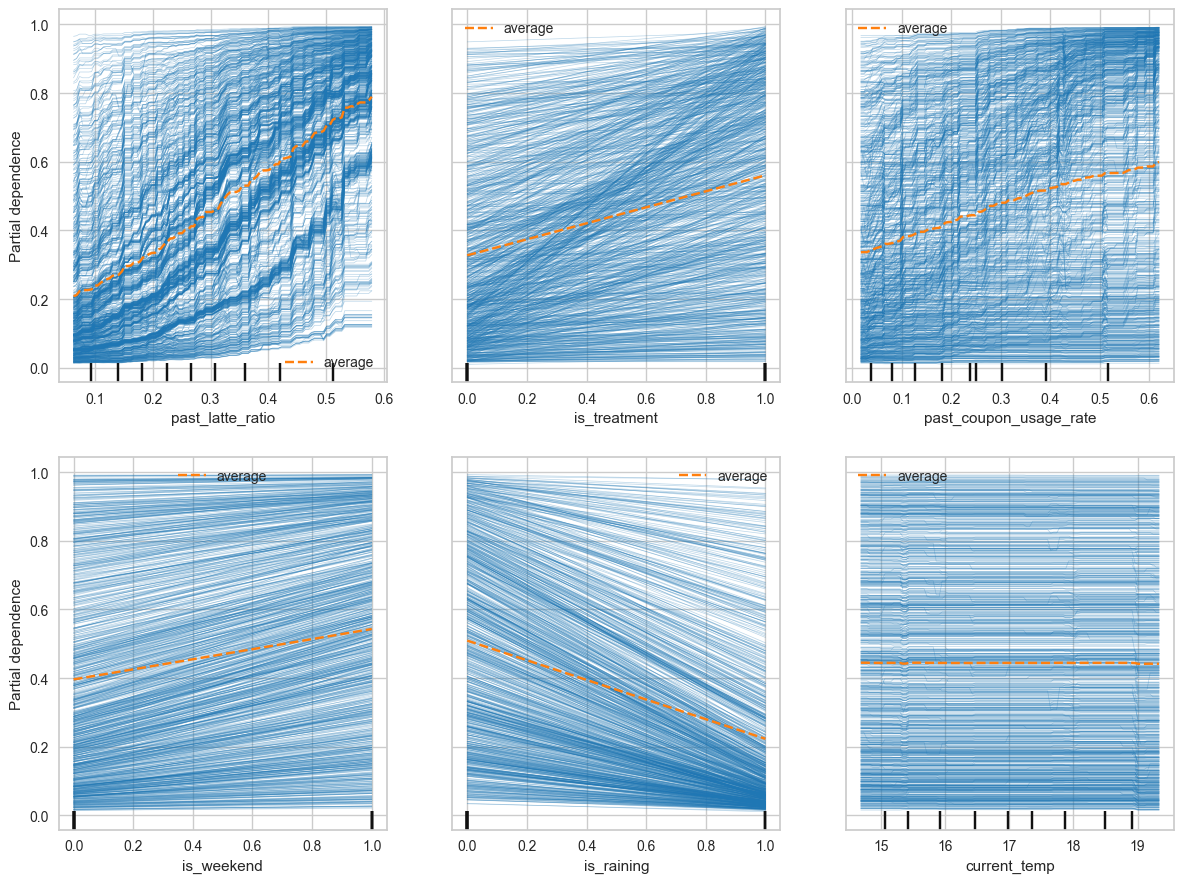

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# どの特徴量のPDPを見たいか指定する

# features = X_test.columns.tolist()
# features = tuned_lgbm.feature_name_



# features = ['past_latte_ratio', 'current_temp']
# features = X_train.columns.tolist()  # 全特徴量のPDPを見たいときはこれでOK
# features = df_shap_importance['feature'].head(5).tolist()

features = ['past_latte_ratio',
 'is_treatment',
 'past_coupon_usage_rate',
 'is_weekend',
 'is_raining',
 'current_temp',
]


# 描画（モデルとデータを渡すだけ）
fig, ax = plt.subplots(figsize=(12, 9))
PartialDependenceDisplay.from_estimator(tuned_lgbm, X_test, features, ax=ax, kind='both')
plt.tight_layout()
plt.show()

# model

PyCaretが裏側で動かしているこれらのアルゴリズムは、大きく分けると「ツリー系」「線形・統計系」「近傍・確率系」に分類できます。


---

**1. ツリー・アンサンブル系（今回の主力候補）**  
複雑な非線形ルールを学習するのが得意なグループです。  

| ID | 名称 | 特徴 | 長所 | 短所 |
| :--- | :--- | :--- | :--- | :--- |
| **gbc** | Gradient Boosting | 逐次的に誤差を修正して木を作る。 | 精度が非常に高く、安定。 | 学習が遅い。並列化が難しい。 |
| **lightgbm** | LightGBM | 木の成長が垂直方向（Leaf-wise）。 | **爆速。** 大規模データに強い。 | 少データで過学習しやすい。 |
| **xgboost** | XGBoost | 正則化を含む勾配ブースティング。 | コンペの定番。欠損値に強い。 | パラメータ調整がやや難しい。 |
| **rf** | Random Forest | 多数の決定木の多数決。 | **安定感抜群。** 過学習しにくい。 | モデルサイズが大きくなる。 |
| **et** | Extra Trees | RFよりさらに分割をランダム化。 | RFよりさらに過学習に強い。 | 重要な特徴を見落とすことも。 |
| **ada** | AdaBoost | 間違えたデータに重みを置く。 | 単純な構造のデータで強い。 | 外れ値（ノイズ）に非常に弱い。 |
| **dt** | Decision Tree | 単一の決定木。 | **解釈性が最高。** 視覚化が容易。 | 精度が低く、過学習の塊。 |

---

**2. 線形・統計系（ベースライン・安定志向）**  
データが直線的（または超平面）に分かれると仮定するグループです。  

| ID | 名称 | 特徴 | 長所 | 短所 |
| :--- | :--- | :--- | :--- | :--- |
| **lr** | Logistic Regression | 確率をシグモイド関数で予測。 | **基準（物差し）**として最適。 | 複雑な関係（非線形）は無理。 |
| **ridge** | Ridge Classifier | L2正則化を加えた線形分類。 | 特徴量が多い時に計算が安定。 | AUC（確率的な評価）が出ない。 |
| **lda** | Linear Disc. Analysis | クラス内分散を最小化する。 | 計算が極めて速い。安定。 | データが正規分布に近い必要。 |
| **qda** | Quadratic Disc. Analysis | 二次曲線で境界線を引く。 | 境界線が曲がっていても対応可。 | パラメータ数が多く不安定。 |
| **svm** | SVM (Linear) | マージンを最大化する。 | 高次元データに比較的強い。 | スケーリングに敏感。解釈困難。 |

---

**3. 近傍・確率・その他（特殊枠）**  
「似たもの探し」や「確率」で判断するグループです。  

| ID | 名称 | 特徴 | 長所 | 短所 |
| :--- | :--- | :--- | :--- | :--- |
| **knn** | K Neighbors | 近くにあるデータk個の多数決。 | 直感的。局所パターンに強い。 | 推論時（予測）が非常に重い。 |
| **nb** | Naive Bayes | 特徴が独立と仮定した確率計算。 | 異常に速い。テキスト分類向き。 | 特徴量間の相関を無視する。 |
| **dummy** | Dummy Classifier | 最頻値だけで予測する等。 | **最低ラインの確認用。** | 予測能力はゼロ。 |

---

この表を眺めると、今回のデータで **`lda`** や **`ridge`** が上位に来ていたのはおもしろいかも。これは、複雑なモデル（LightGBM等）が頑張ってルールを探さなくても、ある程度「線形的（単純な関係）」に説明がつく部分が大きいことを示唆しています。

逆に **`qda`** や **`svm`** が最下位なのは、今回のデータ構造がそれらのロジック（二次曲線やマージン最大化）とは相性が悪かったんだな、と切り捨てることができます。